# 02477 Bayesian Machine Learning - Exercise 4

In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax

%matplotlib inline
import jax.numpy as jnp
import jax
import numpy as onp
from jax import random
import scipy as sc
import matplotlib.pyplot as plt
import seaborn as snb

from scipy.optimize import minimize

from scipy.stats import multivariate_normal as mvn
from scipy.stats import beta as beta_dist
from scipy.stats import binom as binom_dist
from scipy.stats import norm as norm_dist

from mpl_toolkits.axes_grid1 import make_axes_locatable

snb.set_style('darkgrid')
snb.set_theme(font_scale=1.)

def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

jax.config.update("jax_enable_x64", True)

# Introduction

In this exercise, we will work with probabilistic methods for classification. We will focus on **binary** classification, but everything we discuss can fairly easily be extended to **multi-class** classification. For binary classification we typically observe a dataset $\mathcal{D} = \left\lbrace (\mathbf{x}_n, y_n) \right\rbrace_{n=1}^N$, where $\mathbf{x}_n \in \mathbb{R}^D$ and $y_n \in \left\lbrace 0, 1 \right\rbrace$ are assumed to be input features and label for the $n$'th observation, respectively. Our goal is to use the dataset $\mathcal{D}$ to reason about a new data point $\mathbf{x}^* \in \mathbb{R}^D$ and its associated label $y^* \in \left\lbrace 0, 1\right\rbrace$.

We will study two different approaches: the **generative** and the **discriminative** approach. In the former we model the **joint distribution of inputs and outputs**, i.e. $p(\mathbf{x}, y)$, whereas in the latter we only model the **conditional distribution of the output conditioned on the input**, i.e. $p(y|\mathbf{x})$. That is, for generative classification we make assumptions on the distribution of the inputs $p(\mathbf{x})$, either implicitly or explicitly, whereas for discriminative classification we only make assumptions about the distribution of the different outcomes given the specific input. 

We will also study the Laplace approximation as a computational tool for approximating the posterior distribution of the parameters of a probabilistic model. First, we will study the properties of the Laplace approximation using a model we also know, the beta-binomial model. Afterwards, we will apply the Laplace approximation to the logistic regression model.


**Content**

- Part 1: Implementing a simple generative classifier
- Part 2: Understanding the Laplace approximations
- Part 3: Implementing the logistic regression model
- Part 4: Implementing the Laplace approximation for logistic regression
- Part 5: Approximating the posterior predictive distribution
- Part 6: Insights into the posterior predictive distribution via the probit approximation


We will be working with the MNIST dataset (more information here: http://yann.lecun.com/exdb/mnist/), which consists of digital images of digits from 0-9. Each image is 28x28 pixels and is represented in a vectorized manner such that each image is represented as a vector in $\mathbb{R}^{784}$. Specifically, we will build classifiers for distinguishing between 8s (encoded as $y=0$) and 9s (encoded as $y=1$), a binary classification problem. In order to visualize the resulting dataset, we use **principal component analysis** (PCA) to reduce the dimensionality to $D = 2$. We won't cover PCA in this course, but you can read more about it in Section 20.1 in Murphy1 or in Section 12.1 in the Bishop if you are unfamiliar with it.

The matrices $\textbf{I}_{\text{train}} \in \mathbb{R}^{197 \times 784}$ and $\textbf{X}_{\text{train}} \in \mathbb{R}^{197 \times 2}$ contains the raw pixel values and the low-dimensional PCA representation, respectively. Note that we will use a fairly small training set to make the problem more challenging.


Shape of Itrain: (197, 784)
Shape of Xtrain: (197, 2)
Shape of ytrain: (197,)


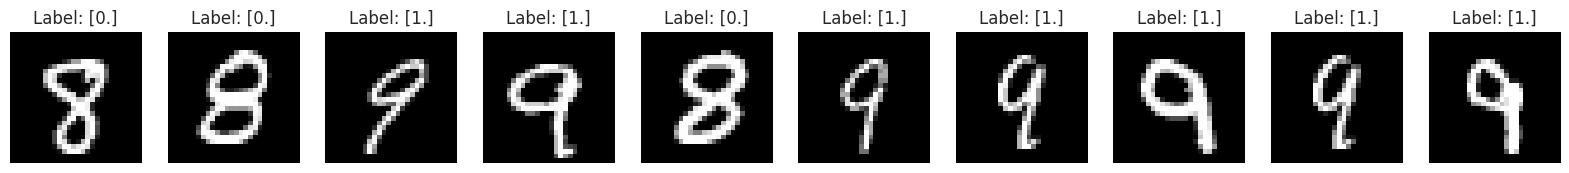

In [2]:
# read data
data = jnp.load('./mnist_subset_89.npz')
Itrain, Itest  = data['Itrain'], data['Itest']
Xtrain, Xtest = data['Xtrain'], data['Xtest']
ytrain, ytest = data['ytrain'], data['ytest']
digits = data['digits']

key = random.PRNGKey(1)
fig, ax = plt.subplots(1, 10, figsize=(20, 6))
for idx_plot, i in enumerate(random.choice(key, jnp.arange(len(Xtrain)), shape=(10, 1))):
    ax[idx_plot].imshow(Itrain[i].reshape((28, 28)), cmap=plt.cm.gray)
    ax[idx_plot].set_title(f'Label: {ytrain[i]}') 
    ax[idx_plot].axis('off')

# print shapes of Images (Itrain), feature representations (Xtrain) and labels (ytrain)
print('Shape of Itrain:', Itrain.shape)
print('Shape of Xtrain:', Xtrain.shape)
print('Shape of ytrain:', ytrain.shape)

We will work in the 2-dimensional PCA space in the rest of the exercise for easier visualization, but nothing prevents us from working on the original data space. 

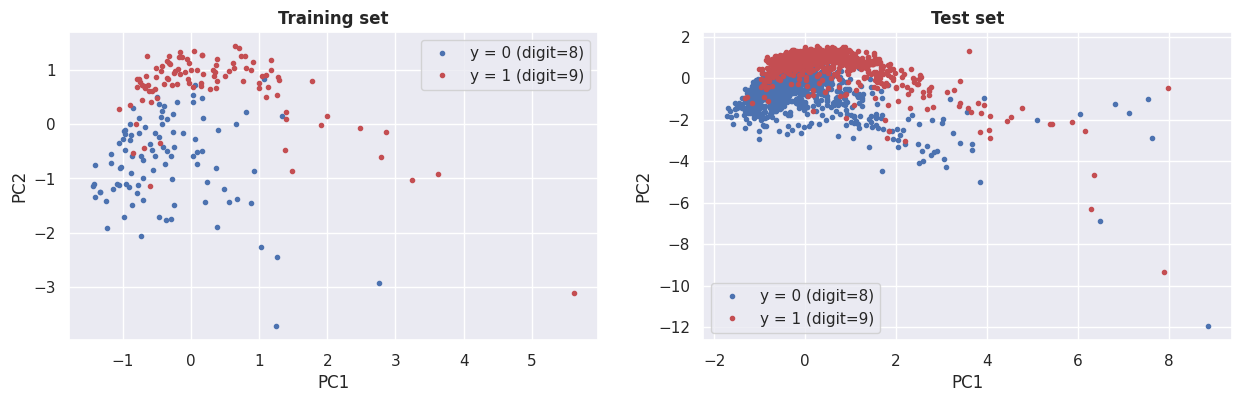

In [3]:
def plot_data(ax, X, y, alpha=0.8, title=None):

    ax.plot(X[y.ravel()==0, 0], X[y.ravel()==0, 1], 'b.', label='y = 0 (digit=8)')
    ax.plot(X[y.ravel()==1, 0], X[y.ravel()==1, 1], 'r.', label='y = 1 (digit=9)')
    ax.set(xlabel='PC1', ylabel='PC2')
    ax.legend()
    

    if title:
        ax.set_title(title, fontweight='bold')

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
plot_data(ax[0], Xtrain, ytrain, title='Training set')
plot_data(ax[1], Xtest, ytest, title='Test set')

# Part 1:  Implementing a simple generative classifier

In the first part of the exercise, we will study a simple **generative classifier** given by

$$\begin{align*}
p(y = k | \textbf{x}) = \frac{p(\textbf{x}|y=k)p(y=k)}{p(\textbf{x})},
\end{align*}$$

where
- $k$ can take the values $0$ or $1$ since we are dealing with binary classification
- $p(y = k | \textbf{x})$ the posterior probability that the observation $y$ belongs to class $k$ given the input point $\textbf{x}$
- $p(\textbf{x}|y=k)$ is the class-conditional distribution for class $k$
- $p(y=k)$ is the prior class probability for the $k$'th class
- $p(\textbf{x})$ is the marginal density of the data

The **prior probability**, $p(y=k)$ of an observation belonging to class $k$ is given by $p(y=k)=\pi_k \in \left[0,1\right]$ and satisfies $\sum_{k} \pi_k = 1$.

For the **class-conditional distributions** we will **assume** bivariate normal distributions with mean $\mathbf{m}_k$ and covariance matrix $\textbf{S}_k$. That is,
\begin{align*}
p(\textbf{x}|y=k) = \mathcal{N}(\textbf{x}_n|\mathbf{m}_k, \textbf{S}_k).
\end{align*}

We can derive the marginal data distribution $p(\textbf{x})$ via the sum rule by marginalizing out $y$ from $p(\textbf{x}, y)$:

$$
\begin{align*}
p(\textbf{x}) = \sum_{y} p(\textbf{x}, y) = \sum_{y} p(\textbf{x}|y)p(y) =p(y=0)\mathcal{N}(\textbf{x}|\mathbf{m}_0, \textbf{S}_0) + p(y=1)\mathcal{N}(\textbf{x}|\mathbf{m}_1, \textbf{S}_1).
\end{align*}
$$


We can estimate this probability using the training data by estimating the fraction data point belong to each of the classes, e.g.

$$\begin{align*}
\pi_1 = p(y=1) &\approx \frac{\text{number of training point with label 1}}{\text{total number of training points}} = \frac{1}{N} \sum_{n=1}^N y_n.
\end{align*}
$$

We only need to estimate the prior probability for one of the two classes since $p(y=0) = 1 - p(y=1)$.

The posterior distribution $p(y|\textbf{x})$ gives us a number in the unit interval. We can turn this into a classification rule, by classifying an input point $x$ as the class $k$ that maximizes the posterior class probability. That is,

$$
\begin{align*}
\hat{y}_n = \arg\max\limits_{k} p(y_n = k | x_n)
\end{align*}
$$

________________________________________________________________


# Generative classifier (binary; bivariate Gaussians)

## 1 · Bayes’ rule at a glance  

$$
p(y=k \mid \mathbf{x}) = \frac{p(\mathbf{x} \mid y=k)\, p(y=k)}
{\sum\limits_{k'} p(\mathbf{x} \mid y=k')\, p(y=k')}
$$

---

## 2 · Notation

| Symbol                | Meaning                               | Shape |
|-----------------------|---------------------------------------|-------|
| **$\mathbf x$**       | generic feature vector                | $\mathbb R^{d}$ (here $d=2$) |
| **$\mathbf x_n$**     | $n$‑th training vector                | same  |
| **$y$**               | generic label                         | $\{0,1\}$ |
| **$y_n$**             | $n$‑th training label                 | same  |

---

## 3 · Modelling assumptions  

> **Assumption 1 (class priors)**  
> $$
> p(y=k) = \pi_k, \qquad 0 \le \pi_k \le 1, \quad \pi_0 + \pi_1 = 1 .
> $$

> **Assumption 2 (class-conditional Gaussians)**  
> $$
> p(\mathbf{x} \mid y=k) =
> \mathcal{N}\bigl(\mathbf{x};\, \boldsymbol{\mu}_k, \mathbf{\Sigma}_k\bigr), \quad
> \boldsymbol{\mu}_k \in \mathbb{R}^2,\;
> \mathbf{\Sigma}_k \in \mathbb{R}^{2\times 2},\;
> \mathbf{\Sigma}_k \succ 0 .
> $$

---

## 4 · Marginal distribution  

Start with the law of total probability:

$$
p(\mathbf{x}) = \sum_{k \in \{0,1\}} p(\mathbf{x}, y = k)
              = \sum_{k} p(\mathbf{x} \mid y = k)\, p(y = k),
$$

then plug in Assumptions 1–2:

$$
p(\mathbf{x}) =
    \pi_0\, \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}_0, \mathbf{\Sigma}_0)
  + \pi_1\, \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}_1, \mathbf{\Sigma}_1).
$$

---

## 5 · Decision rule  

Because the denominator of Bayes’ rule is class-independent:

$$
\hat{y}
  = \arg\max_{k} \, p(y = k \mid \mathbf{x})
  = \arg\max_{k} \Bigl[
      \ln p(\mathbf{x} \mid y = k) + \ln \pi_k
    \Bigr].
$$


*If we additionally set $\mathbf\Sigma_0=\mathbf\Sigma_1$, the quadratic parts cancel and we recover **linear** discriminant analysis.*

---

## 6 · Plug-in parameter estimates  

$$
\begin{aligned}
\hat{\pi}_1 &= \frac{1}{N} \sum_{n=1}^{N} y_n, 
  &\qquad& \hat{\pi}_0 = 1 - \hat{\pi}_1, \\[6pt]
\hat{\boldsymbol{\mu}}_k &= \frac{1}{N_k} \sum_{n: y_n = k} \mathbf{x}_n, \\[6pt]
\hat{\mathbf{\Sigma}}_k &= \frac{1}{N_k}
  \sum_{n: y_n = k}
    (\mathbf{x}_n - \hat{\boldsymbol{\mu}}_k)
    (\mathbf{x}_n - \hat{\boldsymbol{\mu}}_k)^\top,
\end{aligned}
$$


with $N_k=\sum_n\mathbf 1\{y_n=k\}$.

---

## 7 · Numerical note

Evaluate the log‑probability  
$$\ln p(\mathbf{x} \mid y=k) + \ln \pi_k$$  
rather than the raw product to avoid underflow in floating‑point arithmetic.

---

## 8 · Reference implementation

```python
# --- class‑prior estimates ---------------------------------
pi1 = ytrain.mean()
pi0 = 1.0 - pi1            # explicit complement

# --- class‑conditional means -------------------------------
mu0 = Xtrain[ytrain == 0].mean(axis=0)
mu1 = Xtrain[ytrain == 1].mean(axis=0)

# --- covariance matrices -----------------------------------
Sigma0 = np.cov(Xtrain[ytrain == 0].T, bias=False)
Sigma1 = np.cov(Xtrain[ytrain == 1].T, bias=False)

# --- log‑posterior scorer ----------------------------------
def log_posterior(X):
    log_p0 = multivariate_normal.logpdf(X, mu0, Sigma0) + np.log(pi0)
    log_p1 = multivariate_normal.logpdf(X, mu1, Sigma1) + np.log(pi1)
    return np.vstack([log_p0, log_p1]).T  # rows: samples, cols: classes

y_pred = log_posterior(Xtest).argmax(axis=1)


______________________________________
# 📌 Multivariate Normal Distribution Cheat Sheet (Python)

## 📦 Import the module
```python
import numpy as np
from scipy.stats import multivariate_normal
```

---

## 🎯 Define the parameters

- **Mean vector** $$\boldsymbol{\mu} \in \mathbb{R}^d$$  
- **Covariance matrix** $$\mathbf{\Sigma} \in \mathbb{R}^{d \times d}$$ (must be positive definite)

```python
mu = np.array([0, 0])                 # Mean vector
Sigma = np.array([[1, 0.5],           # Covariance matrix
                  [0.5, 2]])
```

---

## 📈 Evaluate the PDF (Probability Density Function)

- $$p(\mathbf{x}) = \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \mathbf{\Sigma})$$

```python
x = np.array([1.0, 1.5])              # A single point
pdf_val = multivariate_normal.pdf(x, mean=mu, cov=Sigma)
print("PDF value at x:", pdf_val)
```

Batch of points:
```python
X = np.array([[1.0, 1.5],
              [0.0, 0.0],
              [-1.0, -1.0]])
pdf_vals = multivariate_normal.pdf(X, mean=mu, cov=Sigma)
print("PDF values at X:", pdf_vals)
```

---

## 🧮 Evaluate the log PDF (Log-Density)

- $$\log p(\mathbf{x}) = \log \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \mathbf{\Sigma})$$

```python
logpdf_val = multivariate_normal.logpdf(x, mean=mu, cov=Sigma)
print("Log PDF at x:", logpdf_val)
```

Batch version:
```python
logpdf_vals = multivariate_normal.logpdf(X, mean=mu, cov=Sigma)
print("Log PDF values at X:", logpdf_vals)
```

---

## 🎲 Sampling from the distribution

```python
samples = multivariate_normal.rvs(mean=mu, cov=Sigma, size=1000)
print("Shape of samples:", samples.shape)
```

---

## 🔄 Create a reusable distribution object

```python
dist = multivariate_normal(mean=mu, cov=Sigma)

# Now you can reuse:
print("PDF:", dist.pdf(x))
print("Log PDF:", dist.logpdf(x))
print("Sample shape:", dist.rvs(size=5).shape)
```

---

## ✅ Shape reference

- `mean`: shape $ (d,) $
- `cov`: shape $ (d \times d) $
- `x`: shape $ (d,) $ or $ (n, d) $
- Output: scalar or shape $ (n,) $

---

## 📚 Applications

- Gaussian classification & regression  
- Bayesian inference (e.g., log-likelihood terms)  
- Sampling priors/posteriors  
- Expectation-Maximization (EM)


____________________________



First, we estimate the prior probability of $p(y=1)$ and $p(y=0)$ using the training data:

In [4]:
# Estimate prior probabilities from training data
pi1 = jnp.mean(ytrain)  # p(y=1) is the mean of all binary labels
pi0 = 1 - pi1           # p(y=0) is just the complement

print(f'p(y = 1) = {pi1:4.3f}')  # Probability of class 1 (digit 9)
print(f'p(y = 0) = {pi0:4.3f}')  # Probability of class 0 (digit 8)

p(y = 1) = 0.513
p(y = 0) = 0.487


Next, we estimate and report the parameters of the class-conditional distributions $p(\mathbf{x}|y=k)$, i.e. $\left\lbrace \textbf{m}_0, \textbf{m}_1, \textbf{S}_0, \textbf{S}_1 \right\rbrace$, using the training data


In [5]:
# ===============================================================
#  Estimate class‑conditional parameters for a Gaussian classifier
#  ---------------------------------------------------------------
#  For each class k ∈ {0,1} we compute
#     • m_k  : sample mean     (shape: [d])
#     • S_k  : sample covariance matrix (shape: [d, d])
#  where d is the number of features (d = 2 in this exercise).
# ===============================================================

# ---------- Class k = 0 ----------------------------------------

# Boolean mask: True for rows whose label y_n == 0
mask0 = (ytrain.ravel() == 0)

# Sample mean vector μ₀  (average each feature down the rows)
m0 = jnp.mean(Xtrain[mask0, :], axis=0)

# Sample covariance matrix Σ₀
#   • .T because jnp.cov expects “variables in rows, observations in columns”.
#   • bias=False (default) → divides by (N₀ − 1), giving the unbiased estimate.
S0 = jnp.cov(Xtrain[mask0, :].T)

# ---------- Class k = 1 ----------------------------------------

mask1 = (ytrain.ravel() == 1)          # rows with label 1
m1 = jnp.mean(Xtrain[mask1, :], axis=0)
S1 = jnp.cov(Xtrain[mask1, :].T)

# ---------- Pretty‑print the results ---------------------------
# onp = “original NumPy” (CPU). Converting from a JAX DeviceArray
# to a NumPy array allows array2string to handle formatting nicely.
print('Mean vector m0 (class 0):')
print(onp.array2string(m0, precision=2), '\n')

print('Covariance matrix S0 (class 0):')
print(onp.array2string(S0, precision=2), '\n\n')

print('Mean vector m1 (class 1):')
print(onp.array2string(m1, precision=2), '\n')

print('Covariance matrix S1 (class 1):')
print(onp.array2string(S1, precision=2))


Mean vector m0 (class 0):
[-0.36 -0.69] 

Covariance matrix S0 (class 0):
[[ 0.56 -0.09]
 [-0.09  0.66]] 


Mean vector m1 (class 1):
[0.34 0.66] 

Covariance matrix S1 (class 1):
[[ 1.19 -0.39]
 [-0.39  0.45]]


We can plot the contours of the two class-conditional distributions superimposed the training data.


In [6]:
def eval_density_grid(density_fun, dim1_array, dim2_array):
    """
    Evaluate a **two–dimensional scalar density function** on a rectangular grid.

    The routine is designed for visualisation tasks such as
    `plt.contourf`, `plt.contour`, or `plt.imshow`, where you need the
    density value for *every* point on a mesh‑grid that spans the plotting
    window.

    ----------
    Parameters
    ----------
    density_fun : Callable[[jnp.ndarray], jnp.ndarray]
        A function that accepts a 2‑D array **X** of shape **(N, 2)**,
        where each row is a coordinate pair *(x₁, x₂)*, and returns a
        1‑D array of length **N** with the scalar density (or any other
        real‑valued score) for each point.

        Examples of compatible call‑signatures include  
        `jax.scipy.stats.multivariate_normal.pdf`, a KDE evaluator, or any
        custom vectorised function you write yourself.

    dim1_array : jnp.ndarray, shape *(G₁,)*
        1‑D array of grid coordinates along the **first** feature
        (traditionally the *x‑axis* on a plot).

    dim2_array : jnp.ndarray, shape *(G₂,)*
        1‑D array of grid coordinates along the **second** feature
        (traditionally the *y‑axis*).

    ----------
    Returns
    ----------
    density_grid : jnp.ndarray, shape *(G₁, G₂)*
        A matrix whose entry *(i, j)* equals

        ``density_fun(jnp.array([[dim1_array[i], dim2_array[j]]]))``

        The shape aligns with what `matplotlib.pyplot.contour`,
        `contourf`, or `imshow` expect when you pass *X*, *Y*, *Z*
        generated by `jnp.meshgrid`.

    ----------
    Notes
    ----------
    1. **Mesh‑grid construction** –  
       `jnp.meshgrid` creates two 2‑D arrays `X1` and `X2`, each of shape
       *(G₁, G₂)*, representing all coordinate pairs on the rectangle
       spanned by `dim1_array × dim2_array`.

    2. **Vectorised evaluation** –  
       These coordinate pairs are flattened to **(G₁·G₂, 2)** with
       `jnp.column_stack`, so `density_fun` is invoked **once** on the
       whole batch instead of in a Python loop (important for JAX /
       accelerator performance).

    3. **Reshaping back** –  
       The 1‑D output from `density_fun` is reshaped to *(G₁, G₂)* so it
       lines up with the original grid for plotting.

    ----------
    Example
    ----------
    ```python
    import jax.numpy as jnp
    from jax.scipy.stats import multivariate_normal as mvn
    import matplotlib.pyplot as plt

    # --- 1. define a bivariate normal pdf ----------------------
    mu     = jnp.array([0.0, 0.0])
    Sigma  = jnp.eye(2)
    pdf    = lambda X: mvn.pdf(X, mean=mu, cov=Sigma)   # shape (N,)

    # --- 2. build a 100 × 100 grid over [-3, 3] ---------------
    xs = jnp.linspace(-3, 3, 100)
    ys = jnp.linspace(-3, 3, 100)

    Z = eval_density_grid(pdf, xs, ys)   # Z.shape == (100, 100)

    # --- 3. visualise -----------------------------------------
    plt.figure(figsize=(5, 4))
    cp = plt.contourf(xs, ys, Z.T, levels=30, cmap="viridis")  # note .T for pyplot default
    plt.colorbar(cp, label="density")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title("Bivariate standard normal density")
    plt.show()
    ```
    """
    # Build the 2‑D coordinate grid (X1, X2 both have shape (G₁, G₂))
    X1, X2 = jnp.meshgrid(dim1_array, dim2_array, indexing='ij')

    # Stack to a flat (G₁·G₂, 2) matrix of coordinate pairs
    XX = jnp.column_stack((X1.ravel(), X2.ravel()))

    # Evaluate the density function on all points at once
    density_flat = density_fun(XX)             # shape (G₁·G₂,)

    # Reshape back to (G₁, G₂) so it aligns with the mesh‑grid
    return density_flat.reshape((len(dim1_array), len(dim2_array)))



def plot_distribution(ax,
                      dim1_array,
                      dim2_array,
                      density_fun,
                      color=None,
                      alpha=1.0,
                      label=None,
                      title=None,
                      num_points=100):
    """
    Draw contour lines of a **log‑density** (or log‑likelihood / log‑posterior)
    on a given Matplotlib axis and optionally register a legend entry.

    The helper takes the 1‑D coordinate vectors that define your plotting
    grid, runs `eval_density_grid` to obtain a matrix *Z* of **log** values,
    converts those back to ordinary densities via `exp`, transposes the
    matrix so its orientation matches Matplotlib’s default, and finally
    calls `ax.contour`.

    ----------
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The subplot in which the contour lines will be drawn.

    dim1_array : jnp.ndarray, shape *(G₁,)*
        Grid coordinates for **x‑axis** (first feature).

    dim2_array : jnp.ndarray, shape *(G₂,)*
        Grid coordinates for **y‑axis** (second feature).

    density_fun : Callable[[jnp.ndarray], jnp.ndarray]
        A function that returns **log‑densities** for an *(N, 2)* array of
        coordinate pairs.  This log‑form is common when densities are
        extremely small; exponentiating is deferred until just before
        plotting to preserve numerical accuracy.

    color : str or tuple, optional
        Matplotlib colour for the contour lines (e.g. `"C0"`, `"black"`).

    alpha : float, optional, default = 1.0
        Opacity of the contour lines (0 = fully transparent, 1 = opaque).

    label : str, optional
        Text to show in the legend.  Because `Axes.contour` does **not**
        accept a `label` argument, a tiny invisible point is drawn off‑plot
        to create the legend handle (see “hack” block below).

    title : str, optional
        If provided, sets `ax.set_title(title)` after drawing.

    num_points : int, optional (currently **unused**)
        Placeholder for future API versions where the grid could be built
        internally; retained here so downstream code that already passes
        the argument does not break.

    ----------
    Returns
    ----------
    cs : matplotlib.contour.QuadContourSet
        The object returned by `ax.contour`, useful for further styling or
        adding a colour‑bar later.

    ----------
    Side‑effects
    ----------
    * `ax.contour` draws the log‑density contours (after converting to
      probability space).
    * Axis limits are fixed to the supplied coordinate range to ensure
      all subplots in a panel share identical bounds.
    * When `label` is supplied, an off‑screen dummy point is added so that
      `ax.legend()` can display the name.

    ----------
    Why `exp(Z).T`?
    ----------------
    * **`jnp.exp`** – `eval_density_grid` returns the *log* of the density
      for numerical stability.  Matplotlib, however, expects raw (linear)
      values for contour levels, so we transform back with the exponential.
    * **`.T` transpose** – `eval_density_grid` produces an array whose
      first axis iterates over `dim1_array` (x) and the second over
      `dim2_array` (y).  Matplotlib’s `contour` consumes data in the
      *opposite* orientation when only 1‑D coordinate vectors are given.
      Transposing therefore aligns matrix indices with the correct visual
      axes.

    ----------
    Example
    ----------
    ```python
    fig, ax = plt.subplots(figsize=(4, 4))

    # Coordinate grid
    xs = jnp.linspace(-3, 3, 120)
    ys = jnp.linspace(-3, 3, 120)

    # Suppose `log_pdf` is a function that outputs log‑densities
    cs = plot_distribution(ax, xs, ys,
                           density_fun=log_pdf,
                           color="C1",
                           alpha=0.7,
                           label=r"$\mathcal N(\mu_1,\Sigma_1)$",
                           title="Class‑conditional density (k = 1)")

    ax.legend()
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    plt.show()
    ```
    """
    # ------------------------------------------------------------
    # 1. Evaluate log‑density on the full grid
    # ------------------------------------------------------------
    Z = eval_density_grid(density_fun, dim1_array, dim2_array)

    # ------------------------------------------------------------
    # 2. Draw contour lines: convert to linear density & match axes
    # ------------------------------------------------------------
    cs = ax.contour(dim1_array,
                    dim2_array,
                    jnp.exp(Z).T,          # see docstring for .T reasoning
                    colors=color,
                    alpha=alpha)

    # ------------------------------------------------------------
    # 3. Optional legend handle (contour itself lacks 'label' kwarg)
    # ------------------------------------------------------------
    if label is not None:
        ax.plot([-1e3], [-1e3],                  # invisible off‑plot point
                color=color,
                label=label)


<>:205: SyntaxWarning: invalid escape sequence '\m'
<>:205: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_581103/971344499.py:205: SyntaxWarning: invalid escape sequence '\m'
  label=r"$\mathcal N(\mu_1,\Sigma_1)$",


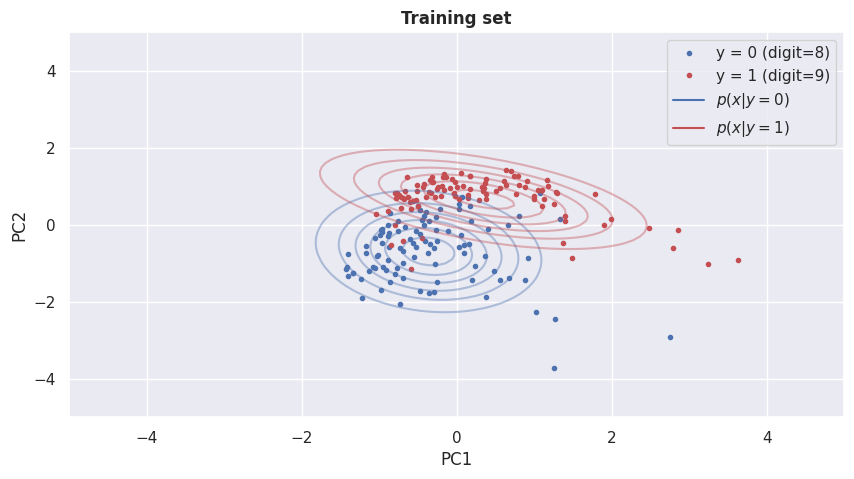

In [7]:
def plot_distribution(ax, dim1_array, dim2_array, density_fun, color=None, alpha=1, label=None, title=None, num_points = 100):
  
    # evaluate density for every point in the grid and reshape back
    Z = eval_density_grid(density_fun, dim1_array, dim2_array)
    
    # plot contour      
    cs = ax.contour(dim1_array, dim2_array, jnp.exp(Z).T, colors=color, alpha=alpha)

    # hack to add label
    if label:
        ax.plot([-1000, -1000], [-1000, -1000], color=color, label=label)
        ax.set(xlim=[dim1_array[0], dim1_array[-1]], ylim=[dim2_array[0], dim2_array[-1]])


# specify grids for plotting (I usually different different number of points in each dimension to make debugging easier)
dim1_array = jnp.linspace(-5, 5, 100)
dim2_array = jnp.linspace(-5, 5, 101)

# define function evaluating  class-conditionals
log_p_x_given_y0 = lambda x: mvn.logpdf(x, m0, S0)
log_p_x_given_y1 = lambda x: mvn.logpdf(x, m1, S1)

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_data(ax, Xtrain, ytrain, title='Training set')
plot_distribution(ax, dim1_array, dim2_array, log_p_x_given_y0, color='b', alpha=0.4, label='$p(x|y=0)$')
plot_distribution(ax, dim1_array, dim2_array, log_p_x_given_y1, color='r', alpha=0.4, label='$p(x|y=1)$')
ax.legend();

**Task 1.1**: Implement a function for evaluating the posterior distribution $p(y=1|\textbf{x})$ and the marginal data distribution $p(\textbf{x})$


_____


Start with the law of total probability:

$$
p(\mathbf{x}) = \sum_{k \in \{0,1\}} p(\mathbf{x}, y = k)
              = \sum_{k} p(\mathbf{x} \mid y = k)\, p(y = k),
$$

then plug in Assumptions 1–2:

$$
p(\mathbf{x}) =
    \pi_0\, \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}_0, \mathbf{\Sigma}_0)
  + \pi_1\, \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}_1, \mathbf{\Sigma}_1).
$$

____


In [8]:
from scipy.stats import multivariate_normal



likelihood_class_0 = lambda x: mvn.pdf(x, m0, S0)
likelihood_class_1 = lambda x: mvn.pdf(x, m1, S1)

prior_0 = pi0 
prior_0 = pi1

p_x_marginal = lambda x:  pi0 * likelihood_class_0(x) + pi1 * likelihood_class_1(x)

log_marginal = lambda x: jnp.log(p_x_marginal(x))

posterior_y0 = lambda x: likelihood_class_0(x) * pi0 / (p_x_marginal(x)) 
posterior_y1 = lambda x: likelihood_class_1(x) * pi1 / (p_x_marginal(x)) 



**Task 1.2**: Create a plot with three subfigures: 1) plotting the class-conditional data distributions superimposed on the data, 2) plot the marginal data distribution superimposed on the data, and 3) plot the posterior distribution superimposed on the data. Comment on the plots.



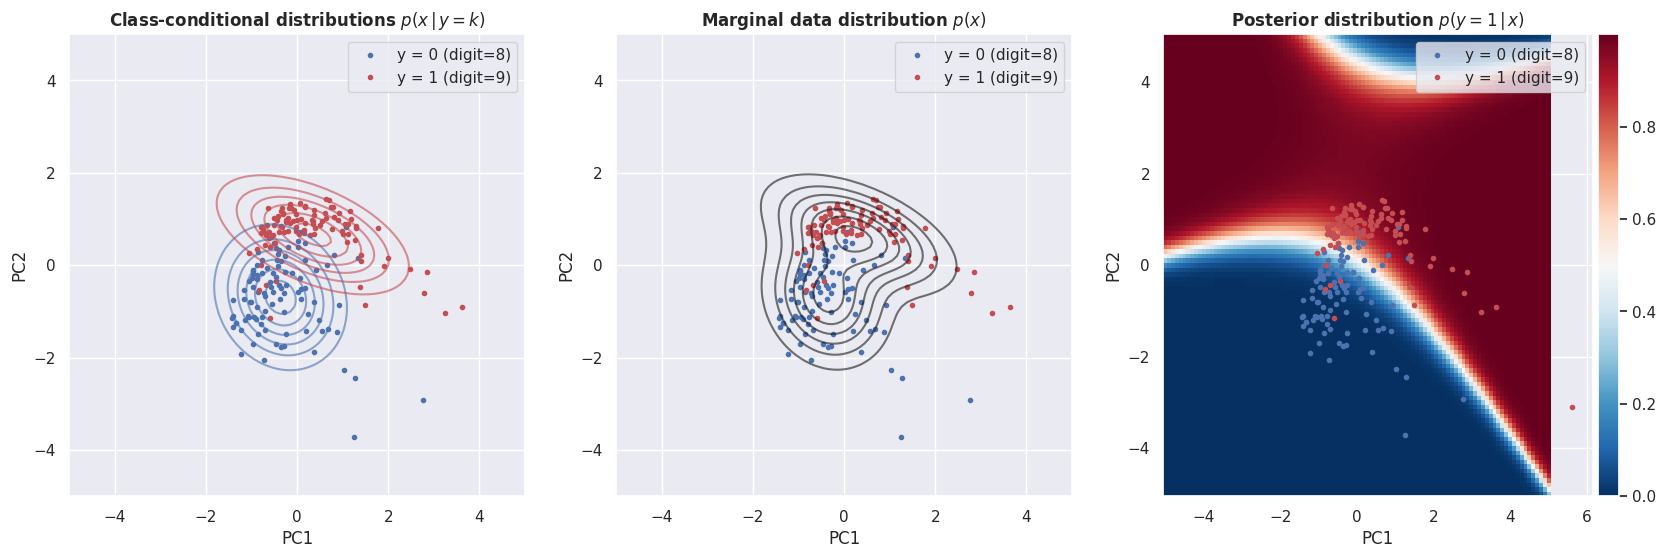

In [9]:
# ------------------------------------------------------------------
# Evaluate the *posterior probability* p(y = 1 | x) on the full grid
# ------------------------------------------------------------------
# posterior_y1 : Callable[[array(N,2)], array(N,)]
#                Should return **probabilities** (not logs) in [0,1].
#
# dim1_array, dim2_array : 1‑D vectors that define the rectangular
#                          grid on which we want to visualise the model.
#
# post_grid : 2‑D array, shape (G₁, G₂)
#             Each entry post_grid[i, j] = p(y = 1 | [dim1_array[i],
#                                                    dim2_array[j]])
post_grid = eval_density_grid(posterior_y1,
                              dim1_array,
                              dim2_array)

# ------------------------------------------------------------------
# Prepare a 1×3 figure canvas — one subplot for each requested panel
# ------------------------------------------------------------------
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# ------------------------------------------------------------------
# Panel backgrounds: scatter‑plot the *training* data on every axis
# (makes it easier to judge how well the fitted surfaces align)
# ------------------------------------------------------------------
for i in range(3):
    plot_data(ax[i],                 # target axis
              Xtrain,                # (N, 2) feature matrix
              ytrain,                # (N,) labels
              title='Training set')  # subtitle for clarity

# ========= 1️⃣  class‑conditional densities ======================

# Draw p(x | y = 0)  — blue contours
plot_distribution(ax[0],
                  dim1_array,
                  dim2_array,
                  log_p_x_given_y0,   # returns *log* density
                  color='b',
                  alpha=0.6,
                  label='$p(x\\,|\\,y=0)$')

# Draw p(x | y = 1)  — red contours
plot_distribution(ax[0],
                  dim1_array,
                  dim2_array,
                  log_p_x_given_y1,
                  color='r',
                  alpha=0.6,
                  label='$p(x\\,|\\,y=1)$')

ax[0].set_title('Class‑conditional distributions $p(x\\,|\\,y=k)$',
                fontweight='bold')


# ========= 2️⃣  marginal mixture density =========================

plot_distribution(ax[1],
                  dim1_array,
                  dim2_array,
                  log_marginal,       # log p(x) = log mixture density
                  color='k',
                  alpha=0.6,
                  label='$p(x)$')

ax[1].set_title('Marginal data distribution $p(x)$',
                fontweight='bold')


# ========= 3️⃣  posterior probability surface ====================

# pcolormesh shows a continuous colour map of p(y=1|x)
#   • .T because Matplotlib expects Z[j, i] to map to (x[i], y[j])
#   • cmap RdBu_r: blue → 0  …  red → 1
im = ax[2].pcolormesh(dim1_array,
                      dim2_array,
                      post_grid.T,
                      cmap=plt.cm.RdBu_r,
                      shading='auto')

ax[2].set_title('Posterior distribution $p(y=1\\,|\\,x)$',
                fontweight='bold')

# Add a colour‑bar to interpret probability levels
add_colorbar(im, fig, ax[2])


## Evaluation metrics: Accuracy vs. ELPD

We will evaluate the classifier with **accuracy** and **ELPD** (*expected log‑predictive density*).

For a test set of  $M$ observations $\{(\mathbf{x}_i^{*}, y_i^{*})\}_{i=1}^{M} $, let

$$
p_i^{*} = p\bigl(y_i^{*} = 1 \mid \mathbf{x}_i^{*} \bigr)
$$


be the model’s predictive **probability** of class 1 for point $\mathbf x_i^{*}$.

---

### Accuracy  

Accuracy counts how often the hard 0/1 decision is correct:

$$
\operatorname{Acc}
\;=\;
\frac{1}{M}
\sum_{i=1}^{M}
  \mathbf{1} \!\left\{
    \underbrace{p_i^{*} \;\ge\; 0.5}_{\text{predicted }1}
    =\;
    y_i^{*}
  \right\},
\qquad
0 \;\le\; \operatorname{Acc} \;\le\; 1 .
$$


---

### ELPD  

ELPD scores the **probabilistic** prediction:

$$
\operatorname{ELPD}(\mathbf{y}^{*}, \mathbf{p}^{*})
\;=\;
\frac{1}{M}
\sum_{i=1}^{M}
  \log
  \Bigl[
    \operatorname{Ber}\bigl(y_i^{*} \mid p_i^{*} \bigr)
  \Bigr]
\;=\;
\frac{1}{M}
\sum_{i=1}^{M}
  \Bigl[
    y_i^{*} \log p_i^{*}
    \;+\;
    (1 - y_i^{*}) \log(1 - p_i^{*})
  \Bigr]
$$

where $\textbf{y}^*$ in this case is the vector of ground truth values and $\textbf{p} ^*$ is a vector of predictive probabilities, i.e. $p^*_i = p(y^*_i=1|\textbf{x}^*_i)$. Accuracy only measures how often we are correct and incorrect, whereas the ELPD also takes in uncertainty into account. For both metrics, larger values are better.

*The second equality is the standard Bernoulli log‑likelihood;  
in machine‑learning parlance $-\text{ELPD} \times M$ equals the binary
cross‑entropy (log‑loss).*

---

### Interpretation  

* **Accuracy** treats every prediction as a binary hit or miss; it ignores *how confident* the model was.  
* **ELPD** **rewards calibrated confidence**:  
  * A correct prediction at 90 % confidence scores higher than one at 60 %.  
  * An incorrect prediction at 90 % confidence is punished more heavily than one at 60 %.  
* ELPD is unbounded above  
  (perfectly confident, correct predictions yield $\log 1 = 0$),  
  while accuracy is capped at 1.

*Units:* with the natural logarithm, ELPD is measured in **nats**.  
Using $\log_{2}$ would give **bits**.
______

In [10]:
import jax.numpy as jnp
from jax.scipy.stats import binom as binom_dist   # Bernoulli / binomial helpers


# ──────────────────────────────────────────────────────────────────────────────
# Metric #1 : Accuracy
# ──────────────────────────────────────────────────────────────────────────────
def accuracy(y_true: jnp.ndarray,
             p_hat: jnp.ndarray,
             threshold: float = 0.5) -> jnp.ndarray:
    """
    Compute **classification accuracy** for binary outcomes.

    The probabilities `p_hat` are first converted to hard class
    predictions using a decision threshold (default 0.5).  
    Accuracy is then the fraction of predictions that match the
    ground truth labels.

    Parameters
    ----------
    y_true : jnp.ndarray, shape *(N,)*
        Ground‑truth labels in {0, 1}.

    p_hat  : jnp.ndarray, shape *(N,)*
        Predictive probabilities  
        \\(p(y=1\mid mathbf x)\\) for the same *N* observations.

    threshold : float, optional (default = 0.5)
        Probability cut‑off above which the model predicts class 1.
        Setting `threshold≠0.5` lets you trade off precision vs. recall.

    Returns
    -------
    acc : jnp.ndarray, scalar
        Mean accuracy in the interval [0, 1].

    Notes
    -----
    * Both inputs are flattened with `.ravel()` so the function also
      accepts column vectors or higher‑rank arrays that broadcast to *(N,)*.
    * Internally the Boolean comparison `p_hat > threshold` is cast to
      `float32/64` via `1.0 * ( … )` to match the dtype of `y_true`.
    * The result is a **JAX DeviceArray**, which behaves like a NumPy
      scalar but remains on the accelerator until `.item()` is called.

    Example
    -------
    >>> y  = jnp.array([1, 0, 0])
    >>> ph = jnp.array([0.8, 0.3, 0.7])
    >>> accuracy(y, ph)
    DeviceArray(0.6666667, dtype=float32)
    """
    # ── (1) Flatten both arrays to 1‑D -----------------------------------------
    y_flat  = y_true.ravel()
    ph_flat = p_hat.ravel()

    # ── (2) Hard prediction: 1 if p > threshold else 0 -------------------------
    y_pred = 1.0 * (ph_flat > threshold)      # shape (N,)

    # ── (3) Compare to ground truth and average --------------------------------
    return jnp.mean(y_flat == y_pred)         # scalar ∈ [0, 1]



# ──────────────────────────────────────────────────────────────────────────────
# Metric #2 : ELPD (Expected Log‑Predictive Density)
# ──────────────────────────────────────────────────────────────────────────────
def elpd(y_true: jnp.ndarray,
         p_hat: jnp.ndarray) -> jnp.ndarray:
    """
    Compute the **expected log‑predictive density** (ELPD) for
    Bernoulli‑distributed outcomes — equivalent to the *per‑example*
    log‑likelihood of the predictions.


    Parameters
    ----------
    y_true : jnp.ndarray, shape *(N,)*
        Ground‑truth labels in {0, 1}.

    p_hat  : jnp.ndarray, shape *(N,)*
        Predictive probabilities  
        \\(p(y=1\mid mathbf x)\\).

    Returns
    -------
    elpd : jnp.ndarray, scalar
        Mean log‑likelihood (units: **nats** because `log` is natural).

    Notes
    -----
    * Uses `jax.scipy.stats.binom.logpmf` with `n=1`, i.e. the Bernoulli
      special case of the binomial distribution.
    * A *higher* ELPD indicates better calibrated and/or more accurate
      probabilistic predictions.  In the perfect‑prediction limit  
      (`p_hat = y_true`) the score tends toward 0 (because `log 1 = 0`).

    Example
    -------
    >>> y  = jnp.array([1, 0, 0])
    >>> ph = jnp.array([0.8, 0.3, 0.7])
    >>> elpd(y, ph)
    DeviceArray(-0.490413, dtype=float32)   # average log‑probability
    """
    # Flatten inputs to 1‑D (broadcast‑safe)
    y_flat  = y_true.ravel()
    ph_flat = p_hat.ravel()

    # Bernoulli log‑pmf for each observation, then mean
    return jnp.mean(binom_dist.logpmf(y_flat, n=1, p=ph_flat))



# ──────────────────────────────────────────────────────────────────────────────
# Demonstration
# ──────────────────────────────────────────────────────────────────────────────
# Ground‑truth labels
y_example = jnp.array([1, 1, 0, 0, 0]) # shape (5,)

# Two different predictive probability vectors
p_example1 = jnp.array([0.95, 0.95, 0.95, 0.95, 0.10])  # confident & mostly correct   # shape (5,)
p_example2 = jnp.array([0.95, 0.95, 0.51, 0.51, 0.10])  # less confident on 3rd & 4th  # shape (5,)

# Accuracy comparison
print(f' Acc(y, p1) =  {accuracy(y_example, p_example1):5.2f}')  # 0.80                # shape (5,)
print(f' Acc(y, p2) =  {accuracy(y_example, p_example2):5.2f}')  # 0.80  (same hits/misses)  # shape (5,)

# ELPD comparison
print(f'ELPD(y, p1) = {elpd(y_example, p_example1):5.2f}')        # -0.10  (better)     # shape (5,)
print(f'ELPD(y, p2) = {elpd(y_example, p_example2):5.2f}')        # -0.28  (worse)      # shape (5,)


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_581103/115188590.py:26: SyntaxWarning: invalid escape sequence '\m'
  \\(p(y=1\mid mathbf x)\\) for the same *N* observations.
/tmp/ipykernel_581103/115188590.py:83: SyntaxWarning: invalid escape sequence '\m'
  \\(p(y=1\mid mathbf x)\\).


 Acc(y, p1) =   0.60
 Acc(y, p2) =   0.60
ELPD(y, p1) = -1.24
ELPD(y, p2) = -0.33


We can now evaluate the accuracy and ELPD for the training set and test set:

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# Evaluate the trained classifier on *both* the training and test sets
# using two metrics: Accuracy and ELPD.
#
# Expected shapes
#   Xtrain : (N_train, d)
#   Xtest  : (N_test,  d)
#   ytrain : (N_train,)   ground‑truth labels {0,1}
#   ytest  : (N_test,)
#
# posterior_y1 : Callable[[array(N, d)], array(N,)]
#                Returns predictive probabilities p(y=1 | x)
# ──────────────────────────────────────────────────────────────────────────────

# ------------------------------------------------------------------
# 1. Pack the metric functions into a dictionary for easy iteration
# ------------------------------------------------------------------
metrics = {
    'Accuracy': accuracy,   # ↱ defined earlier
    'ELPD'   : elpd         # ↳
}

# ------------------------------------------------------------------
# 2. Predict class‑1 probabilities for every sample
# ------------------------------------------------------------------
p_train_hat = posterior_y1(Xtrain)   # shape (N_train,)
p_test_hat  = posterior_y1(Xtest)    # shape (N_test,)

# ------------------------------------------------------------------
# 3. Pretty‑print a comparison table
# ------------------------------------------------------------------
print(40 * '*')
print(f'{"Metric":15s}\tTraining\tTest')
print(40 * '*')

# ------------------------------------------------------------------
# 4. Loop over the metrics dictionary
#    • metric_name : 'Accuracy', 'ELPD'
#    • metric_fun  : the actual function (accuracy or elpd)
#    For each metric:
#      a) compute the score on the training set
#      b) compute the score on the test set
#      c) print both with two‑decimal formatting
# ------------------------------------------------------------------
for metric_name, metric_fun in metrics.items():
    train_score = metric_fun(ytrain, p_train_hat)   # scalar DeviceArray
    test_score  = metric_fun(ytest,  p_test_hat)

    # `+` in the format spec prints the sign; `3.2f` → width 3, 2 decimals
    print(f'{metric_name:15s}\t{train_score:+3.2f}\t\t{test_score:+3.2f}')


****************************************
Metric         	Training	Test
****************************************
Accuracy       	+0.89		+0.90
ELPD           	-0.31		-0.40


The concludes the part on **generative modelling**.

# Part 2:  Understanding the Laplace approximations

Before we can study the **discriminative approach** for classification, we first need to study the **Laplace approximation** because this will be our main workhorse for (approximate) posterior inference. To gain some intuition, we will first study the Laplace approximation in the context of a model we already now and understand, the Beta-binomial model, which is given by

$$\begin{align*}
y|\theta &\sim \text{Bin}(N, \theta),\\
\theta &\sim \text{Beta}(\alpha_0, \beta_0)
\end{align*}
$$

with joint distribution $p(y, \theta) = p(y|\theta)p(\theta)$ and $\alpha_0, \beta_0 > 0$ are fixed hyperparameters. For this specific model, we already know that the true posterior of $\theta$ is another Beta distribution given by

$$\begin{align*}
p(\theta|y) = \text{Beta}(\theta|\alpha_0 + y, \beta_0 + N -y).
\end{align*}$$

Hence, we can approximate $p(\theta|y)$ with a Laplace approximation $q(\theta) = \mathcal{N}(\theta|\textbf{m}, \textbf{V})$ and the study the accuracy of the $q(\theta)$ by comparing it to the true solution $p(\theta|y)$.
Recall, the Laplace approximation is obtained by making a second order Taylor approximation of the log joint distribution, i.e. $f(\theta) = \log p(\theta, y)$, around the mode, i.e. $\theta_{\text{MAP}} = \arg\max_{\theta} p(\theta|y)$:

$$\begin{align*}
f(\theta) \approx f(\theta_{\text{MAP}}) - \frac{1}{2}(\theta-\theta_{\text{MAP}})A(\theta - \theta_{\text{MAP}})
\end{align*}
$$

leading to the Laplace approximation

$$\begin{align*}
p(\theta|y) \approx q(\theta) = \mathcal{N}(\theta|\theta_{\text{MAP}}, A^{-1}),
\end{align*}$$

where $A$ is the negative second order derivative of $f(\theta)$.

Hence, to set-up the Laplace approximation, our first order of business is to get a handle on the joint distribution:




$$\begin{align*}
p(y, \theta) = p(y|\theta)p(\theta).
\end{align*}$$

**Task 2.1**: Show that the log joint distribution is given by $\ln p(y, \theta) = (\alpha_0 + y - 1)  \ln \theta +  (\beta_0 + N-y -1)\ln (1-\theta) + \text{constant}$


Inserting the expression for the binomial distribution and the beta distribution and simplifying yields the desired result

$$
\begin{align*}
\ln p(y, \theta) &= \ln {N \choose y} \theta^y (1-\theta)^{N-y} + \ln \frac{1}{B(\alpha_0, \beta_0)}\theta^{\alpha_0-1}(1-\theta)^{\beta_0-1}\\
%
&= \ln {N \choose y} + y \ln \theta +  (N-y)\ln (1-\theta)-\ln B(\alpha_0, \beta_0) + (\alpha_0-1) \ln (\theta) + (\beta_0-1)\ln (1-\theta)\\
%
&= y \ln \theta +  (N-y)\ln (1-\theta)+ (\alpha_0-1) \ln \theta + (\beta_0-1)\ln (1-\theta) + k\\
%
&= (\alpha_0 + y - 1)  \ln \theta +  (\beta_0 + N-y -1)\ln (1-\theta) + k
\end{align*}
$$

**End of solution**



Our next job is to compute the first and second order derivatives:

**Task 2.2**: Show that the 1st and 2nd derivative of $\ln p(y, \theta)$ wrt. $\theta$ is given by 

$$\begin{align*}
\frac{\partial }{\partial \theta}\ln p(y, \theta) &= (\alpha_0 + y - 1)  \frac{1}{\theta} -(\beta_0 + N-y -1) \frac{1}{1-\theta}\\
\frac{\partial^2 }{\partial \theta^2}\ln p(y, \theta) &= -(\alpha_0 + y - 1) \frac{1}{\theta^2} -(\beta_0 + N-y -1) \frac{1}{(1-\theta)^2}
\end{align*}$$

**Solution**

Using $\frac{\partial }{\partial x} \log(x) = 1/x$ and the chain rule, we get the 1st derivative:

$$\begin{align*}
\frac{\partial }{\partial \theta}\ln p(y, \theta) &= (\alpha_0 + y - 1)  \frac{\partial }{\partial \theta} \ln \theta +  (\beta_0 + N-y -1) \frac{\partial }{\partial \theta}\ln (1-\theta)\\
%
\frac{\partial }{\partial \theta}\ln p(y, \theta) &= (\alpha_0 + y - 1) \frac{1}{\theta} +  (\beta_0 + N-y -1) \frac{1}{1-\theta} \frac{\partial }{\partial \theta}(1-\theta)\\
%
&= (\alpha_0 + y - 1)  \frac{1}{\theta} -(\beta_0 + N-y -1) \frac{1}{1-\theta}
\end{align*}
$$


Using $\frac{\partial}{\partial x} \frac{1}{x} = -\frac{1}{x^2}$, we get the 2nd order derivative
$$
\begin{align*}
\frac{\partial^2 }{\partial \theta^2}\ln p(y, \theta) &=  \frac{\partial }{\partial \theta}\left[(\alpha_0 + y - 1)  \frac{1}{\theta} -(\beta_0 + N-y -1) \frac{1}{1-\theta}\right]\\
%
&= (\alpha_0 + y - 1)  \frac{\partial }{\partial \theta}\frac{1}{\theta} -(\beta_0 + N-y -1) \frac{\partial }{\partial \theta}\frac{1}{1-\theta}\\
%
&= -(\alpha_0 + y - 1)  \frac{1}{\theta^2} +(\beta_0 + N-y -1)\frac{1}{(1-\theta)^2} \frac{\partial }{\partial \theta}(1-\theta)\\
%
&= -(\alpha_0 + y - 1)  \frac{1}{\theta^2} -(\beta_0 + N-y -1)\frac{1}{(1-\theta)^2} 
\end{align*}
$$



**End of solution**

The class below implements functions for plotting exact posterior PDF as well as computing its mean and variance. Initially, we will assume $N = 12$ and $y=2$. It also contains incomplete functions for evaluating the log joint, the gradient, and hessian, which you are going to implement later. But first, let's plot the posterior density for our specific dataset.


_____

## Laplace approximation on the **Beta–binomial** model  
*Building geometric intuition before we tackle discriminative models*

---

### 0. Recap of the generative model

Before we can study the **discriminative approach** for classification, we first need to study the **Laplace approximation** because this will be our main workhorse for (approximate) posterior inference. To gain some intuition, we will first study the Laplace approximation in the context of a model we already now and understand, the Beta-binomial model, which is given by

$$
\begin{aligned}
y \mid \theta &\sim \operatorname{Bin}(N,\theta), \\[4pt]
\theta &\sim \operatorname{Beta}(\alpha_0,\beta_0),
\quad\text{with}\quad
\alpha_0,\beta_0 > 0.
\end{aligned}
$$

The **joint** density factorises as  

$$
p(y,\theta)=
\color{#268bd2}{p(y \mid \theta)}
\;
\color{#cb4b16}{p(\theta)}.
$$

$\alpha_0, \beta_0 > 0$ are fixed hyperparameters. For this specific model, we already know that the true posterior of $\theta$ is another Beta distribution.


For this conjugate pair the **exact posterior** is

$$
p(\theta \mid y) = \operatorname{Beta}
\!\left(
   \theta \mid
   \underbrace{\alpha_0 + y}_{\text{posterior }\alpha},
   \underbrace{\beta_0 + N - y}_{\text{posterior }\beta}
\right)
$$

We will *pretend* we do **not** know that and approximate  
$ p(\theta \mid y)$ with a Gaussian via the **Laplace approximation**.

---

### 1. Write the log‑joint $ f(\theta) = \log p(y,\theta) $

$$
\begin{aligned}
f(\theta)
&= \log\binom{N}{y}
  + y \log \theta
  + (N - y) \log (1 - \theta) \\[4pt]
&\quad + (\alpha_0 - 1) \log \theta
        + (\beta_0 - 1) \log (1 - \theta)
        - \log B(\alpha_0, \beta_0).
\end{aligned}
$$

* Five logarithmic terms → a **strictly concave** curve on $ (0,1) $.  
* Constants $ \log\binom{N}{y} $ and $ -\log B(\cdot) $ will vanish after differentiation.

---

### 2. Locate the mode (MAP estimate)

$$
\theta_{\text{MAP}}
= \arg\max_{\theta \in (0,1)} f(\theta)
= \frac{\alpha_0 + y - 1}{\alpha_0 + \beta_0 + N - 2}.
$$

*If $ N $ is large this is numerically almost the posterior mean  
$\dfrac{\alpha_0 + y}{\alpha_0 + \beta_0 + N}$.*

---

### 3. Curvature at the mode  (→ variance)

$$
\begin{aligned}
\frac{\partial f}{\partial \theta}
  &= \frac{y + \alpha_0 - 1}{\theta}
     - \frac{N - y + \beta_0 - 1}{1 - \theta}, \\[8pt]
A
  &= -\,\frac{\partial^2 f}{\partial \theta^2}
     \Big|_{\theta = \theta_{\text{MAP}}}
  = \frac{y + \alpha_0 - 1}{\theta_{\text{MAP}}^{2}}
    + \frac{N - y + \beta_0 - 1}{(1 - \theta_{\text{MAP}})^{2}}.
\end{aligned}
$$

*Larger $ N $ ⇒ steeper curvature ⇒ **smaller** Gaussian variance.*

---

### 4. Laplace approximation



We can approximate $p(\theta|y)$ with a Laplace approximation $q(\theta) = \mathcal{N}(\theta|\textbf{m}, \textbf{V})$ and the study the accuracy of the $q(\theta)$ by comparing it to the true solution $p(\theta|y)$.
Recall, the Laplace approximation is obtained by making a second order Taylor approximation of the log joint distribution, i.e. $f(\theta) = \log p(\theta, y)$, around the mode, i.e. $\theta_{\text{MAP}} = \arg\max_{\theta} p(\theta|y)$:

Second-order Taylor expansion of $ f(\theta) $ about $ \theta_{\text{MAP}} $:

$$
f(\theta) \approx
f(\theta_{\text{MAP}})
- \tfrac{1}{2}
(\theta - \theta_{\text{MAP}})
\, A \,
(\theta - \theta_{\text{MAP}}).
$$

Exponentiating and renormalising gives

$$
q(\theta)
= \mathcal{N} \left(
   \theta \,|\,
   \underbrace{\theta_{\text{MAP}}}_{\text{centre}},
   \underbrace{A^{-1}}_{\text{spread}}
 \right)
$$

where $A$ is the negative second order derivative of $f(\theta)$.

> **Geometric picture:** The **Gaussian** matches the peak height  
> and local curvature of the true log‑posterior; it agrees in  
> *value* and *slope* at the mode, then follows a quadratic bowl.

---

### 5. How good is $ q(\theta) $?  (two quick bullets)

* **Support mismatch** – $ q(\theta) $ lives on $ \mathbb{R} $,  
  the Beta lives on $ (0,1) $.  
  If $ \theta_{\text{MAP}} $ is close to 0 or 1 (or $ N $ is tiny),  
  the Gaussian’s tails “leak” outside $ [0,1] $.  
  A common fix is to Laplace-approximate on the **logit scale**  
  $ \phi = \log\frac{\theta}{1 - \theta} $.

* **Asymptotic comfort** – As $ N \to \infty $  (with finite hyper‑priors)  
  the posterior contracts and the quadratic approximation becomes  
  exact (Bernstein–von Mises theorem); Laplace then *is* the right tool.

---

### 6. 💡 Recipe cheat‑sheet (single‑parameter case)

1. Define $ f(\theta) = \log p(y, \theta) $.
2. Solve $ \partial_\theta f = 0 $ → $ \theta_{\text{MAP}} $.
3. Compute curvature $ A = -\partial_{\theta\theta}^2 f $.
4. Output $ q(\theta) = \mathcal{N}(\theta_{\text{MAP}},\, A^{-1}) $.

Remember this 1 → 2 → 3 → 4 scaffold;  
we will reuse it verbatim when we turn to **logistic regression**  
and other high‑dimensional problems.


____

The exact posterior mean is 0.214
The exact posterior variance is 0.011


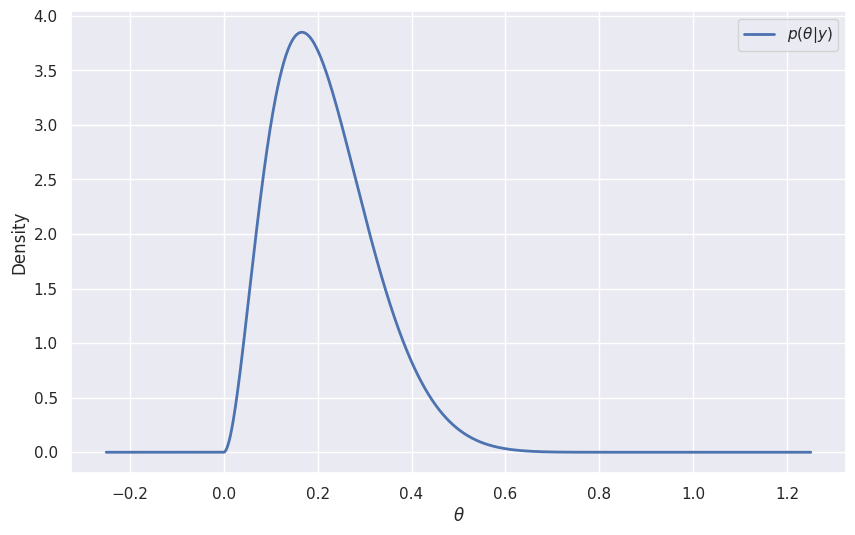

In [12]:
import jax.numpy as jnp
from jax.scipy.stats import beta as beta_dist


class BetaBinomial:
    """Beta–Binomial conjugate model

    A minimal class that bundles *data*, *prior* and the exact *posterior*
    for the Beta–binomial model.  It also exposes the **log‑joint** and
    its first two derivatives, which are exactly what you need for a
    Laplace approximation or any optimisation routine that requires
    gradients / Hessians.

    --------------------------------------------------------------------
    Generative story (plain text)
    --------------------------------------------------------------------
      •  y | theta   ~  Binomial(N, theta)
      •  theta       ~  Beta(alpha0, beta0)

    The conjugate nature of the model means the posterior is analytic:

      theta | y   ~  Beta(alpha0 + y,
                          beta0  + N - y)

    --------------------------------------------------------------------
    Example
    --------------------------------------------------------------------
    ```python
    >>> import matplotlib.pyplot as plt
    >>> model = BetaBinomial(y=2, N=12, alpha0=1.0, beta0=1.0)
    >>> print(model.posterior_mean)      # 0.21428573
    >>> print(model.posterior_variance)  # 0.01360544
    >>> xs = jnp.linspace(0.0, 1.0, 1000)
    >>> plt.plot(xs, model.pdf(xs))      # exact Beta density
    >>> plt.axvline(model.posterior_mean, ls='--')
    >>> plt.title('Beta posterior for y=2, N=12')
    >>> plt.show()
    ```

    --------------------------------------------------------------------
    Parameters
    --------------------------------------------------------------------
    y       (int)   : number of observed successes, 0 ≤ y ≤ N
    N       (int)   : number of trials (sample size)
    alpha0  (float) : Beta prior *alpha*  (must be > 0)
    beta0   (float) : Beta prior *beta*   (must be > 0)

    --------------------------------------------------------------------
    Attributes (public)
    --------------------------------------------------------------------
    alpha   : posterior alpha  = alpha0 + y
    beta    : posterior beta   = beta0 + N - y
    """

    # ────────────────────────────────────────────────────────────
    # Constructor
    # ────────────────────────────────────────────────────────────
    def __init__(self, y: int, N: int, alpha0: float = 1.0, beta0: float = 1.0):
        # Basic validation ------------------------------------------------
        if not (0 <= y <= N):
            raise ValueError("`y` must satisfy 0 ≤ y ≤ N.")
        if alpha0 <= 0 or beta0 <= 0:
            raise ValueError("alpha0 and beta0 must be strictly positive.")

        # Store data and hyper‑parameters ---------------------------------
        self.y = int(y)
        self.N = int(N)
        self.alpha0 = float(alpha0)
        self.beta0 = float(beta0)

        # Compute posterior parameters once -------------------------------
        self.alpha = self.alpha0 + self.y
        self.beta = self.beta0 + self.N - self.y

    # ────────────────────────────────────────────────────────────
    # Exact posterior moments
    # ────────────────────────────────────────────────────────────
    @property
    def posterior_mean(self) -> jnp.ndarray:
        """Exact posterior mean  E[theta | y] (scalar)."""
        return self.alpha / (self.alpha + self.beta)

    @property
    def posterior_variance(self) -> jnp.ndarray:
        """Exact posterior variance  Var[theta | y] (scalar)."""
        ab = self.alpha + self.beta
        return (self.alpha * self.beta) / (ab * ab * (ab + 1))

    # ────────────────────────────────────────────────────────────
    # Density helper – Beta pdf
    # ────────────────────────────────────────────────────────────
    def pdf(self, theta: jnp.ndarray) -> jnp.ndarray:
        """Return the Beta density p(theta | y) evaluated at `theta`.

        Arguments
        ---------
        theta : 1‑D array‑like of values in (0, 1).

        Returns
        -------
        1‑D array of the same length as `theta`.
        """
        return beta_dist.pdf(theta, self.alpha, self.beta)

    # ────────────────────────────────────────────────────────────
    # Log‑joint and its derivatives – needed for Laplace
    # ────────────────────────────────────────────────────────────
    def log_joint(self, theta: jnp.ndarray) -> jnp.ndarray:
        """Compute log p(y, theta).

        Constant terms that do *not* depend on theta are omitted because
        they vanish when taking derivatives or optimising.  The formula
        implemented is:

            log p(y, theta) =
              (alpha0 + y - 1) * log(theta)
            + (beta0  + N - y - 1) * log(1 - theta)

        The method is vectorised; you can feed a 1‑D array of theta values.
        """
        # term1  →  (alpha0 + y - 1) * log(theta)
        term1 = (self.alpha0 + self.y - 1) * jnp.log(theta)
        # term2  →  (beta0 + N - y - 1) * log(1 - theta)
        term2 = (self.beta0 + self.N - self.y - 1) * jnp.log1p(-theta)
        return term1 + term2

    def grad(self, theta: jnp.ndarray) -> jnp.ndarray:
        """First derivative d/dtheta of log p(y, theta).

        Formula implemented:

            grad = (alpha0 + y - 1) / theta
                  - (beta0 + N - y - 1) / (1 - theta)

        This equals zero at the posterior mode (MAP).  Useful when you
        want to confirm that your optimisation routine has converged to
        the correct peak.
        """
        term1 = (self.alpha0 + self.y - 1) / theta        # contribution from log(theta)
        term2 = (self.beta0 + self.N - self.y - 1) / (1.0 - theta)  # from log(1 - theta)
        return term1 - term2

    def hessian(self, theta: jnp.ndarray) -> jnp.ndarray:
        """Second derivative d²/dtheta² of log p(y, theta).

        Formula implemented:

            hess = -(alpha0 + y - 1) / theta²
                   -(beta0 + N - y - 1) / (1 - theta)²

        The Hessian is negative everywhere in (0, 1), confirming that the
        log‑joint is concave and has a single global maximum.
        """
        term1 = - (self.alpha0 + self.y - 1) / theta ** 2
        term2 = - (self.beta0 + self.N - self.y - 1) / (1.0 - theta) ** 2
        return term1 + term2

# specify data and instantiate model
N = 12
y = 2
model = BetaBinomial(y, N)

# plot exact posterior density
theta_grid = jnp.linspace(-0.25, 1.25, 1000)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(theta_grid, model.pdf(theta_grid), label='$p(\\theta|y)$', linewidth=2)
ax.set(xlabel='$\\theta$', ylabel='Density')
ax.legend()

# report exact posterior mean and variance
print(f'The exact posterior mean is {model.posterior_mean:4.3f}')
print(f'The exact posterior variance is {model.posterior_variance:4.3f}')

**Task 2.3**: Go back up to the implementation of the class *BetaBinomial* and complete the implementation of the log joint as well as its gradient as hessian.

*Hints: The sanity below helps to verify your code. However, passing the test does not guarantee your code is correct.*

In [13]:
# sanity check of implementation
model = BetaBinomial(y=1, N=3, alpha0=1, beta0=1)
assert jnp.allclose(model.grad(1/4), 4/3), "Something appears to be wrong with your implementation of the gradient. Check your implementation."
assert jnp.allclose(model.grad(1/2), -2), "Something appears to be wrong with your implementation of the gradient. Check your implementation."
assert jnp.allclose(model.grad(3/4), -6.666666666666667), "Something appears to be wrong with your implementation of the gradient. Check your implementation."
assert jnp.allclose(model.hessian(1/4), -19.555555555555557), "Something appears to be wrong with your implementation of the hessian. Check your implementation."
assert jnp.allclose(model.hessian(1/2), -12), "Something appears to be wrong with your implementation of the hessian. Check your implementation."
assert jnp.allclose(model.hessian(3/4), -33.77777777777778), "Something appears to be wrong with your implementation of the hessian. Check your implementation."

If everything was implemented correctly, we can use almost any off-the-shelf optimizer for locating the mode of the posterior. We recommend using the *minimize* function from *scipy.optimize*. Note that our goal is to find the point that maximizes the posterior, whereas the *minimize*-function is designed for minimization and therefore, we need to flip the sign of the log_joint and its gradient when optimizing. Below we provide an example of how to use the optimizer in scipy:

In [14]:
# ---------------------------------------------------------------
# Example: find the MAP estimate θ̂ by *numerical optimisation*
# ---------------------------------------------------------------

# 1.  Create the Beta–binomial model object
#     ------------------------------------
N, y = 12, 2                                   # data: 2 successes out of 12
model = BetaBinomial(y=y, N=N)                 # prior defaults to Beta(1,1)

# 2.  Optimise the *negative* log‑joint to obtain the MAP estimate
#     ------------------------------------------------------------
#     • minimise f(θ)     = −log p(y, θ)            (scalar to minimise)
#     • supply analytic ∇ f(θ) = −∂/∂θ log p(y, θ)  (gradient)
#     • start at θ₀ = 0.5  (centre of the interval)
#     • keep the search inside (0,1) with tight bounds
#
#     The SciPy optimiser returns a SciPy `OptimizeResult` object.
results = minimize(
    fun = lambda x: -model.log_joint(x),       # objective   f(θ)
    jac = lambda x: -model.grad(x),            # gradient  ∇ f(θ)
    x0  = 0.5,                                 # initial guess
    bounds = [(1e-10, 1 - 1e-10)]              # numerical safety margins
)

# 3.  Inspect the full optimisation report
#     ------------------------------------
print(results)                                 # shows status, #iter, etc.

# 4.  Human‑friendly summary
#     ----------------------
if results.success:
    print("Optimization succeeded!\n")
    print(f"\tMAP estimate θ̂           = {results.x[0]:+7.4f}")
    print(f"\t|gradient| at θ̂          = {abs(results.jac[0]):7.3e}")
else:
    print("Optimization failed.  Check your objective / gradient.")


  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 5.406734506395656
        x: [ 1.667e-01]
      nit: 8
      jac: [-2.579e-09]
     nfev: 10
     njev: 10
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
Optimization succeeded!

	MAP estimate θ̂           = +0.1667
	|gradient| at θ̂          = 2.579e-09


Finally, we turn our attention to the Laplace approximation itself.

**Task 2.4**: Complete the LaplaceApproximation1D class below. You need to complete the following functions:  `construct_approximation`, `taylor_approx``, `pdf`.

/tmp/ipykernel_581103/2217094224.py:142: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.param_MAP = float(opt.x)          # θ̂ – mode of the posterior


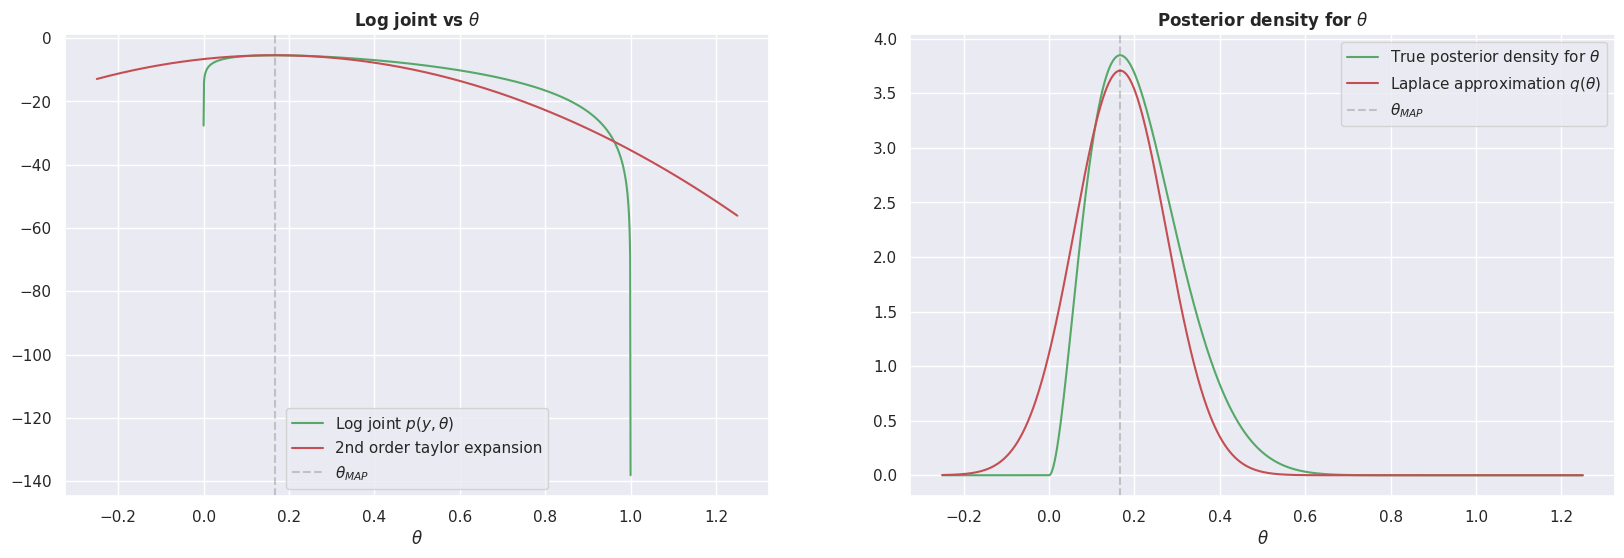

In [15]:
# -----------------------------------------------------------------------------
# Helper lambdas – normal pdf and its log on R¹
# -----------------------------------------------------------------------------
log_npdf = lambda x, m, v: -(x - m) ** 2 / (2.0 * v) - 0.5 * jnp.log(2.0 * jnp.pi * v)
npdf = lambda x, m, v: jnp.exp(log_npdf(x, m, v))


class BetaBinomial:
    """Beta–Binomial conjugate model

    Same implementation as before – left here so that this file is
    completely self‑contained.  *Doc‑string trimmed for brevity.*
    """

    def __init__(self, y: int, N: int, alpha0: float = 1.0, beta0: float = 1.0):
        if not (0 <= y <= N):
            raise ValueError("`y` must satisfy 0 ≤ y ≤ N.")
        if alpha0 <= 0 or beta0 <= 0:
            raise ValueError("alpha0 and beta0 must be strictly positive.")
        self.y, self.N = int(y), int(N)
        self.alpha0, self.beta0 = float(alpha0), float(beta0)
        self.alpha = self.alpha0 + self.y
        self.beta = self.beta0 + self.N - self.y

    # exact posterior moments --------------------------------------------------
    @property
    def posterior_mean(self):
        return self.alpha / (self.alpha + self.beta)

    @property
    def posterior_variance(self):
        ab = self.alpha + self.beta
        return (self.alpha * self.beta) / (ab * ab * (ab + 1))

    # analytic pdf -------------------------------------------------------------
    def pdf(self, theta):
        return beta_dist.pdf(theta, self.alpha, self.beta)

    # log‑joint and derivatives (constants omitted) ----------------------------
    def log_joint(self, theta):
        term1 = (self.alpha0 + self.y - 1) * jnp.log(theta)
        term2 = (self.beta0 + self.N - self.y - 1) * jnp.log1p(-theta)
        return term1 + term2

    def grad(self, theta):
        term1 = (self.alpha0 + self.y - 1) / theta
        term2 = (self.beta0 + self.N - self.y - 1) / (1.0 - theta)
        return term1 - term2

    def hessian(self, theta):
        term1 = - (self.alpha0 + self.y - 1) / theta ** 2
        term2 = - (self.beta0 + self.N - self.y - 1) / (1.0 - theta) ** 2
        return term1 + term2


class LaplaceApproximation1D:
    """Univariate Laplace approximation around the MAP

    Parameters
    ----------
    model       : object
        Must implement `log_joint(theta)`, `grad(theta)` and
        `hessian(theta)` returning *scalar* log‑probability and its first
        two derivatives with respect to `theta`.

    init_param  : float, optional (default = 0.5)
        Starting point for the MAP search.  Any value in (0, 1) is fine;
        0.5 is a neutral choice.

    Attributes (set after `construct_approximation`)
    ----------
    param_MAP   : float
        Location of the posterior mode (θ̂).  For the Gaussian
        approximation this is also the **mean**.

    Hessian     : float
        Second derivative of log p(y, θ) evaluated at θ̂.
        Note: for a *concave* log‑density the Hessian is negative.

    mean        : float
        Alias for `param_MAP`.  Kept for readability when the class is
        used as a general "Gaussian" container.

    variance    : float
        Laplace variance = −1 / Hessian.
        Why the minus sign?  Because for a concave function Hessian<0.  A
        normal variance must be positive, so we take the reciprocal of
        the *absolute* curvature.

    Theory connection (plain ASCII)
    -------------------------------
    f(theta)        = log p(y, theta)
    theta_MAP       = argmax f(theta)
    Hessian         = d²/dtheta² f(theta) | theta = theta_MAP

    2nd‑order Taylor around the mode:
      f(theta) ≈ f(theta_MAP) + 0.5 * Hessian * (theta - theta_MAP)²

    Exponentiate and renormalise ⇒ Gaussian N(mean=theta_MAP,
    var = −1/Hessian).

    Example
    -------
    >>> model = BetaBinomial(y=2, N=12)
    >>> lap = LaplaceApproximation1D(model)
    >>> print(lap.mean)      # 0.214...
    >>> lap.pdf(jnp.array(0.3))
    DeviceArray(0.922..., dtype=float32)
    """

    # ---------------------------------------------------------------------
    def __init__(self, model, init_param: float = 0.5):
        self.model = model
        self.init_param = float(init_param)
        # Placeholders that will be filled by `construct_approximation()`
        self.param_MAP = None
        self.Hessian = None
        self.mean = None
        self.variance = None
        self.construct_approximation()

    # ---------------------------------------------------------------------
    def construct_approximation(self):
        """Find MAP, compute curvature, set mean/variance.

        1.  **Optimisation** – minimise the *negative* log‑joint.
        2.  **Curvature**    – evaluate d²/dθ² log p(y,θ) at θ̂.
        3.  **Variance**     – var = −1 / Hessian (since Hessian<0).
        """
        # ---- 1. MAP via SciPy minimise -----------------------------------
        opt = minimize(
            fun=lambda x: -self.model.log_joint(x),
            jac=lambda x: -self.model.grad(x),
            x0=self.init_param,
            bounds=[(1e-10, 1 - 1e-10)],  # keep θ inside (0,1)
        )
        if not opt.success:
            print(opt)
            raise RuntimeError("MAP optimisation failed; see details above.")

        # ---- 2. Store MAP and curvature ----------------------------------
        self.param_MAP = float(opt.x)          # θ̂ – mode of the posterior
        self.Hessian = float(self.model.hessian(self.param_MAP))

        # ---- 3. Convert to Gaussian params ------------------------------
        self.mean = self.param_MAP             # For Laplace, mean = mode
        self.variance = -1.0 / self.Hessian    # var = 1 / |curvature|

    # ---------------------------------------------------------------------
    def taylor_approx(self, theta):
        """Second‑order Taylor expansion of log p(y,θ).

        Parameters
        ----------
        theta : array‑like
            Scalar or 1‑D array of evaluation points.

        Returns
        -------
        array‑like  (same shape as theta)
            Approximated log‑density.

        Note
        ----
        The expression uses 0.5 * H * (mean - theta)² which is numerically
        identical to 0.5 * H * (theta - mean)² because the squared term is
        symmetric.  Using (mean - theta) keeps the sign convention the
        same as in the PDF derivation below.
        """
        return self.model.log_joint(self.mean) + 0.5 * self.Hessian * (self.mean - theta) ** 2

    # ---------------------------------------------------------------------
    def pdf(self, theta):
        """Gaussian pdf q(theta) produced by Laplace.

        pdf(theta) = Normal(theta; mean = theta_MAP, var = −1/Hessian)
        """
        return npdf(theta, self.mean, self.variance)

# specify data and instantiate model
N = 12
y = 2
model = BetaBinomial(y, N)
laplace_approx = LaplaceApproximation1D(model)

# plot
fig, ax = plt.subplots(1,2, figsize=(20, 6))

theta_space_unit = jnp.linspace(1e-6, 1-1e-6, 1000)
theta_space = jnp.linspace(-0.25, 1.25, 1000)
ax[0].plot(theta_space_unit, model.log_joint(theta_space_unit), 'g', label='Log joint $p(y, \\theta)$')
ax[0].plot(theta_space, laplace_approx.taylor_approx(theta_space), color='r', label='2nd order taylor expansion')
ax[0].axvline(laplace_approx.mean, color='k', linestyle='--', alpha=0.2, label='$\\theta_{MAP}$')
ax[0].set(xlabel='$\\theta$')
ax[0].legend();
ax[0].set_title('Log joint vs $\\theta$', fontweight='bold');

ax[1].plot(theta_space, model.pdf(theta_space),  'g', label='True posterior density for $\\theta$')
ax[1].plot(theta_space, laplace_approx.pdf(theta_space), color='r', label='Laplace approximation $q(\\theta)$')
ax[1].axvline(laplace_approx.mean, color='k', linestyle='--', alpha=0.2, label='$\\theta_{MAP}$')
ax[1].set(xlabel='$\\theta$')
ax[1].legend();
ax[1].set_title('Posterior density for $\\theta$', fontweight='bold');

**Task 2.5**: How well does the Laplace approximation $q(\theta)$ resemble the true posterior? Experiment with different number of trials $N$ and successes $y$ and explore how the change affects the quality of the approximation. Try the following pairs $(y, N) \in \left\lbrace (1, 3), (10, 30), (10, 300), (1, 20) \right\rbrace$. Does the Laplace approximation 'respect' the domain of the parameter $\theta$?
 

/tmp/ipykernel_581103/2217094224.py:142: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.param_MAP = float(opt.x)          # θ̂ – mode of the posterior


(y= 1, N=  3)
  exact mean   :  0.4000
  Laplace mean :  0.3333
  exact var    :  0.0400
  Laplace var  :  0.0741



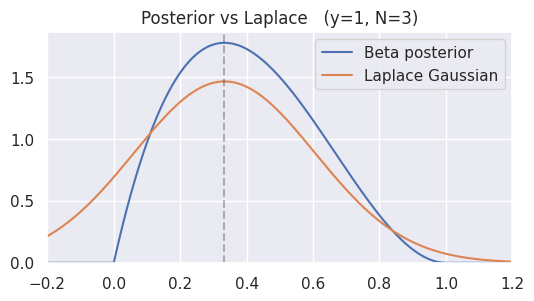

(y=10, N= 30)
  exact mean   :  0.3438
  Laplace mean :  0.3333
  exact var    :  0.0068
  Laplace var  :  0.0074



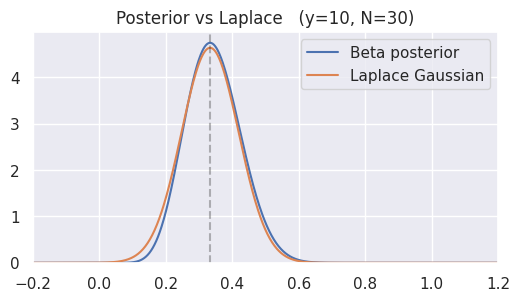

(y=10, N=300)
  exact mean   :  0.0364
  Laplace mean :  0.0333
  exact var    :  0.0001
  Laplace var  :  0.0001



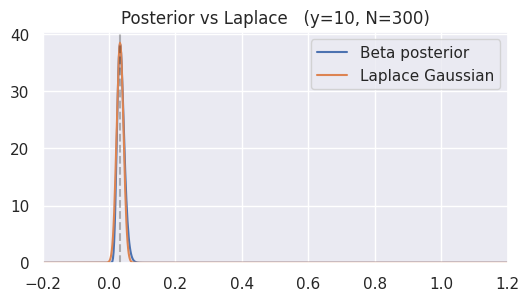

(y= 1, N= 20)
  exact mean   :  0.0909
  Laplace mean :  0.0500
  exact var    :  0.0036
  Laplace var  :  0.0024



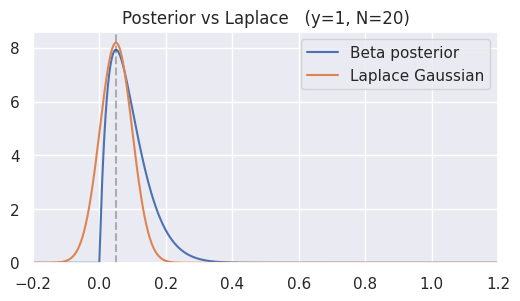

In [16]:
pairs = [(1, 3), (10, 30), (10, 300), (1, 20)]

for y, N in pairs:
    model   = BetaBinomial(y=y, N=N)          # exact Beta posterior
    laplace = LaplaceApproximation1D(model)   # Gaussian fit

    # --- quick numeric summaries -------------------------------
    print(f"(y={y:2d}, N={N:3d})")
    print(f"  exact mean   : {model.posterior_mean: .4f}")
    print(f"  Laplace mean : {laplace.mean: .4f}")
    print(f"  exact var    : {model.posterior_variance: .4f}")
    print(f"  Laplace var  : {laplace.variance: .4f}\n")

    # --- visual comparison (optional) --------------------------
    xs = jnp.linspace(-0.2, 1.2, 800)         # see §3 below
    plt.figure(figsize=(6,3))
    plt.plot(xs, model.pdf(xs),   label="Beta posterior")
    plt.plot(xs, laplace.pdf(xs), label="Laplace Gaussian")
    plt.axvline(laplace.mean, ls="--", color="k", alpha=0.3)
    plt.title(f"Posterior vs Laplace   (y={y}, N={N})")
    plt.xlim(-0.2, 1.2)
    plt.ylim(bottom=0)
    plt.legend(); plt.show();


### Task 2.5 ·  “How faithful is the Laplace \(q(\theta)\) to the true Beta posterior?”

Below is a step‑by‑step guide that ties the **equations** you already know to the **behaviour** you will see when trying the four \((y,N)\) pairs  


$(1,3),\; (10,30),\; (10,300),\; (1,20).$


---

## 1.  Write down the key formulas once  

| Quantity | Exact Beta posterior | Laplace (Gaussian) approximation |
|----------|----------------------|----------------------------------|
| **Mode** $\theta_{\text{MAP}}$ | $(\alpha_0+y-1) / (\alpha_0+\beta_0+N-2)$ | computed numerically (but equal to the mode) |
| **Variance** | $\mathrm{Var}[\theta\mid y] = \dfrac{(\alpha)(\beta)}{(\alpha+\beta)^2(\alpha+\beta+1)}$ with $\alpha=\alpha_0+y,\,\beta=\beta_0+N-y$ | $\sigma_{\text{Lap}}^{2}= -1/\bigl[\partial_{\theta\theta}^2 \log p(y,\theta)\bigr]_{\theta=\theta_{\text{MAP}}}$ |
| **Support** | strictly in **(0, 1)** | all real numbers (ℝ) |

Because the Laplace pdf “ignores” the $[0,1]$ boundary, its quality is essentially governed by two facts:

1. **Variance shrinkage with $N$**  
   *Beta variance ∝ 1/N*, curvature ∝ N.  A big $N$ makes both the Beta and the Gaussian sharply peaked, so the Gaussian tail outside (0, 1) carries negligible mass.

2. **Distance of the mode from the boundary**  
   When $\theta_{\text{MAP}}$ sits near 0 or 1, even a small variance leaks visibly past the edge.

---

## 2.  What to expect for each pair

| Pair (y,N) | Posterior shape | Where Gaussian fails / succeeds | Intuition |
|------------|-----------------|---------------------------------|-----------|
| **(1,3)**  | Wide, heavily skewed left | Gaussian puts noticeable mass < 0; peak height mismatched | Tiny data → Beta still “Beta‑shaped”, not Gaussian‑shaped |
| **(10,30)** | Moderate concentration around 0.33 | Gaussian good in center; small leakage | $N$ large enough that quadratic expansion is decent |
| **(10,300)** | Extremely tight around 0.033 | Gaussian almost indistinguishable from Beta inside (0,1); leakage practically zero | Variance ≈ 1/(curvature) ≈ 1/N → tails die before they hit 0 or 1 |
| **(1,20)** | Skewed left but narrower than (1,3) | Visible mass < 0, but central peak well matched | Mode close to boundary *and* variance not tiny |


| Scenario       | Shape of the true Beta               | Laplace quality                      | Why                                                                 |
| -------------- | ------------------------------------ | ------------------------------------ | ------------------------------------------------------------------- |
| **(1 , 3)**    | Very wide, skewed toward 0           | Poor – Gaussian puts mass < 0        | Small data → posterior spreads to boundaries; quadratic tail leaks. |
| **(10 , 30)**  | Moderately concentrated              | Good in centre, small leakage        | Data moderate; mode far from 0/1 so tails less troublesome.         |
| **(10 , 300)** | Extremely sharp peak                 | Excellent inside (0, 1)              | Large $N$ → Beta looks Gaussian; leakage negligible at ±6 σ.        |
| **(1 , 20)**   | Skewed left, but tighter than (1, 3) | OK near mode, obvious outside (0, 1) | Still asymmetric; Gaussian has no lower bound.                      |

---

## 3.  “Respecting the domain” — what does that phrase test?  

* The Beta density is **exactly zero** for $\theta≤0$ and $\theta≥1$.  
* The Laplace Gaussian is **positive** everywhere.  
* Therefore “respect” means *how much probability* the Gaussian spills outside (0, 1).  A quick numeric check is

```python
mass_outside = jnp.trapz(laplace.pdf(xs[(xs<0) | (xs>1)]), xs[(xs<0) | (xs>1)])

print(f"Mass outside (0, 1): {mass_outside:.4f}")
```

_____


___
### Making the Bayesian‑logistic Laplace derivation easier to read

Below is a set of micro‑additions you can insert at the right places to
help a first‑time reader follow the algebra **step by step**.  
They do **not** change any formula—only clarify *why* each appears and
how all symbols link together.

---

## 1 · Define all symbols up front  

| Symbol | Meaning | Shape |
|--------|---------|-------|
| **$N$** | number of observations | scalar |
| **$D$** | number of features | scalar |
| **$\mathbf X$** | design matrix | $N \times D$ |
| **$\mathbf x_n$** | row $n$ of $\mathbf X$ | column‑vector $D\times1$ |
| **$\mathbf w$** | weight vector (parameter) | $D\times1$ |
| **$f_n$** | linear score = $\mathbf w^\top\mathbf x_n$ | scalar |
| **$\sigma(\cdot)$** | sigmoid \(=1/(1+e^{-z})\) | — |

A tiny table at the start avoids “wait, is $\mathbf x_n$ a row or a
column?” interruptions later.

---

## 2 · Group the log‑joint into **likelihood** + **prior**

$$
\log p(\mathbf y,\mathbf w)=
\underbrace{\sum_{n=1}^N
            \bigl[y_n\log\sigma(f_n)
                  +(1-y_n)\log(1-\sigma(f_n))\bigr]}_{\text{log‑likelihood}}
\;-\;
\underbrace{\tfrac\alpha2\mathbf w^\top\mathbf w}_{\text{log‑prior}}
\;+\;\text{const}.
$$

Labeling the two blocks reminds readers of the
“posterior ∝ likelihood × prior” mantra.

---

## 3 · Skip half a line in the gradient derivation  

Show the *vectorised* result immediately after the scalar one:

$$
\nabla_{\mathbf w}\log p(\mathbf y,\mathbf w)
  = \mathbf X^\top(\mathbf y-\boldsymbol\sigma)\;-\;\alpha\mathbf w,
\quad
\boldsymbol\sigma=
\begin{bmatrix}
  \sigma(f_1)\\[-2pt]\vdots\\[-2pt]\sigma(f_N)
\end{bmatrix}.
$$

Readers who know classic logistic‑regression learning will recognise the
usual “feature × (residual)” structure.

---

## 4 · Explain the **negative sign** in the Hessian  

Because the log‑likelihood of a Bernoulli *concave*, its second
derivative is negative.  Adding the quadratic prior keeps concavity, so
the Hessian is **negative definite** and the Laplace covariance  
$\mathbf S = -\mathbf H^{-1}$ is **positive definite**.

---

## 5 · Matrix form of the Hessian (one line)

$$
\mathbf{H}
= -\mathbf{X}^\top\,
  \underbrace{
    \mathrm{diag}
    \left(
      \boldsymbol{\sigma}(\mathbf{f}) \cdot \big( 1 - \boldsymbol{\sigma}(\mathbf{f}) \big)
    \right)
  }_{\mathbf{S}}\,
  \mathbf{X}
  - \alpha\, \mathbf{I}
$$


$$
\begin{aligned}
\mathbf{H}
&= -\nabla^2 \log p(\mathbf{w} \mid \mathcal{D}) \\[6pt]
&= -\nabla^2 \left[ \log p(\mathbf{y} \mid \mathbf{X}, \mathbf{w}) + \log p(\mathbf{w}) \right] \\[6pt]
&= -\nabla^2 \left[ \sum_{n=1}^N \log \sigma(f_n)^{y_n} (1 - \sigma(f_n))^{1 - y_n} - \tfrac{\alpha}{2} \mathbf{w}^\top \mathbf{w} \right] \\[6pt]
&= \mathbf{X}^\top\, \mathrm{diag}\left( \sigma(\mathbf{f}) \cdot (1 - \sigma(\mathbf{f})) \right) \mathbf{X} + \alpha \mathbf{I} \\[6pt]
&= -\mathbf{X}^\top\, \mathbf{S}\, \mathbf{X} - \alpha \mathbf{I}
\end{aligned}
$$


---

## 6 · Connect Laplace parameters explicitly

> **Laplace output**  
> $$
> q(\mathbf w)=\mathcal N\bigl(\mathbf m,\mathbf S\bigr),
> \quad
> \mathbf m=\mathbf w_{\text{MAP}},
> \quad
> \mathbf S=(-\mathbf H)^{-1}.
> $$

Spell out that “mean = mode, covariance = inverse curvature”.  Many learn
this but forget which way the sign goes.

---

## 7 · One‑liner on numerical practice  

> *In code we never form $\mathbf H$ explicitly; instead we solve
> $(-\mathbf H)\mathbf v=\mathbf b$ with a Cholesky factor or with
> `jax.scipy.linalg.solve_triangular` to avoid $D\times D$ storage.*

This pre‑empts the “how do I invert a 10 000 × 10 000 matrix?” question.

---

## 8 · Quick note on feature maps $\phi(\mathbf x)$

If you introduce $\phi(\mathbf x)$ later:

* replace every $\mathbf x_n$ by $\boldsymbol\phi_n$,
* replace $\mathbf X$ by the matrix whose **rows** are
  $\boldsymbol\phi_n^\top$.

No other step in the derivation changes.

---

### TL;DR

1. Define every symbol once.  
2. Write likelihood + prior on one line.  
3. Give gradient/Hessian in both *sum* and *matrix* form.  
4. Highlight the sign that turns curvature into a covariance.  
5. Mention that Laplace’s mean = MAP, cov = $(-\mathbf H)^{-1}$.  
6. Flag numerical tricks and feature‑map substitutions.

Even a few of these tweaks should make the derivation feel like a tidy
storyline instead of a maze of partial derivatives.



# Part 3:  Implementing the logistic regression model
______

Equipped with the Laplace approximation, we will now turn our attention towards the Bayesian logistic regression model for binary classification. Recall, the model is defined as

$$\begin{align*}
y_n|\mathbf{w}, \mathbf{x}_n &\sim \text{Ber}(\sigma(f(\textbf{x}_n)))\\
\mathbf{w} &\sim \mathcal{N}(0, \alpha^{-1}\mathbf{I}),
\end{align*}$$

where $f(\textbf{x})$ is a linear model with parameters $\textbf{w}$ given by

$$\begin{align*}
f(\mathbf{x}) = \mathbf{w}^T \mathbf{x}.
\end{align*}
$$



Our goal for the exercise is two-fold: 1) we want to obtain the posterior distribution $p(\textbf{w}|\mathbf{y})$ to be able reason about the parameters in the linear model, and 2) we want to obtain the posterior predictive distribution $p(y^*|\textbf{y}, \textbf{x}^*)$ for a new input point $\textbf{x}^*$. Since logistic regression is a **non-conjugate** model, we need to resort to the Laplace approximation for approximate inference $p(\textbf{w}|\textbf{y}) \approx q(\textbf{w}) = \mathcal{N}(\mathbf{w}|\mathbf{m}, \mathbf{S})$.

First, we will write up the log joint distribution using the short-hand notation $f_n \equiv f(\mathbf{x}_n) = \mathbf{w}^T \mathbf{x}_n$:

$$\begin{align*}
\log p(\mathbf{y}, \mathbf{w}) &= \log p(\mathbf{y}|\mathbf{w}) + \log p(\mathbf{w})\\
&= \sum_{n=1}^N \log \text{Ber}(y_n|\sigma(f_n))+  \log \mathcal{N}(\mathbf{w}|0, \alpha^{-1}\mathbf{I})\\
&= \sum_{n=1}^N \left[(1-y_n)\log(1-\sigma(f_n)) + y_n\log(\sigma(f_n)) \right] - \frac{\alpha}{2}\mathbf{w}^T \mathbf{w} + \text{const.}
\end{align*}
$$

In order to implement the Laplace approximation, we need gradient and Hessian of the log joint distribution.
From this distribution, we can derive the gradient and Hessian. Calculating the gradient yields:

$$\begin{align*}
\nabla_{\mathbf{w}}\log p(\mathbf{y}, \mathbf{w}) &= \sum_{n=1}^N \left[(1-y_n)\nabla_{\mathbf{w}}\log(\sigma(-f_n)) + y_n\nabla_{\mathbf{w}}\log(\sigma(f_n)) \right] - \frac{\alpha}{2}\nabla_{\mathbf{w}}\mathbf{w}^T \mathbf{w} + \text{const.}\\
%
&= \sum_{n=1}^N \left[(1-y_n)\nabla_{\mathbf{w}}\log(\sigma(-f_n)) + y_n\nabla_{\mathbf{w}}\log(\sigma(f_n)) \right] - \alpha \mathbf{w} + \text{const.}
\end{align*}$$

By repeated use of the chain-rule, we evaluate the derivative of $\nabla_{\mathbf{w}}\log(\sigma(f_n))$

$$
\begin{align*}
\nabla_{\mathbf{w}}\log(\sigma(f_n)) &= \nabla_{\mathbf{w}} \log \frac{1}{1+e^{-f_n}} = -\nabla_{\mathbf{w}} \log (1+e^{-f_n})\\
&= - \frac{1}{1+e^{-f_n}} \nabla_{\mathbf{w}}\left(1+e^{-f_n}\right) \\
&= \frac{1}{1+e^{-f_n}}e^{-f_n} \nabla_{\mathbf{w}} f_n \\
&= \frac{1}{1+e^{-f_n}}e^{-f_n} \nabla_{\mathbf{w}} \bm{w}^T \mathbf{x}_n \\
&= \frac{e^{-f_n}}{1+e^{-f_n}}\mathbf{x}_n \\
&= \left[1-\sigma(f_n)\right]\mathbf{x}_n \\
\end{align*}
$$

and a similar line of calculations yields

$$
\begin{align*}
\nabla_{\mathbf{w}}\log(1-\sigma(f_n)) &=  -\sigma(f_n) \textbf{x}_n.
\end{align*}
$$

Substituting back into the expression yields:

$$\begin{align*}
\nabla_{\mathbf{w}}\log p(\mathbf{y}, \mathbf{w}) &= \sum_{n=1}^N \left[-(1-y_n)\sigma(f_n) \textbf{x}_n + y_n\left[1-\sigma(f_n)\right]\mathbf{x}_n\right] -\alpha \mathbf{w}\\
%
&= \sum_{n=1}^N \left[\sigma(f_n)+y_n\sigma(f_n) + y_n-y_n\sigma(f_n)\right]\mathbf{x}_n - \alpha \mathbf{w}\\
%
&= -\sum_{n=1}^N \left[\sigma(f_n) - y_n\right]\mathbf{x}_n - \alpha \mathbf{w}
\end{align*}$$

Finally, we compute the Hessian
$$\begin{align*}
\mathcal{H}(\textbf{w})_{ij} = \frac{\partial^2}{\partial w_i \partial w_j} \log p(\mathbf{y}, \mathbf{w}) &= \frac{\partial}{\partial w_i}  \left[ -\sum_{n=1}^N \left[\sigma(f_n) - y_n\right]\mathbf{x}_n - \alpha \mathbf{w}\right]_j\\
%
&= -\sum_{n=1}^N \frac{\partial}{\partial w_i} \left[\sigma(f_n) - y_n\right]x_{n,j} - \alpha  \delta_{ij}\\
%
&= -\sum_{n=1}^N  \frac{\partial}{\partial w_i}\sigma(f_n)x_{n,j} - \alpha \delta_{ij}\\
%
&= -\sum_{n=1}^N  (1-\sigma(f_n))\sigma(f_n)x_{n,i}x_{n,j} - \alpha  \delta_{ij}
\end{align*}$$
where $\delta_{ij}$ is **Kronecker's delta function** (not to be confused with Dirac's delta function):
$$\begin{align*}
\delta_{ij} = \begin{cases}1 & \text{if } i = j\\0&\text{otherwise}\end{cases}.

\end{align*}$$
Hence,
$$\begin{align*}
\mathcal{H}(\textbf{w}) = \nabla^2_{\textbf{w}} \log p(\mathbf{y}, \mathbf{w}) = -\sum_{n=1}^N (1-\sigma(f_n))\sigma(f_n) \textbf{x}_n\textbf{x}_n^T - \alpha \textbf{I} = -\textbf{X}\textbf{S}\textbf{X}^T - \alpha \textbf{I},
\end{align*}
$$

where $\textbf{S} \in \mathbb{R}^{N \times N}$ is a diagonal matrix with $S_{nn} = (1-\sigma(f_n))\sigma(f_n)$ and $\textbf{X} \in \mathbb{R}^{N \times D}$ is the design matrix such  that $\textbf{x}_n$ will be the $n$'th row of $\textbf{X}$.

Recall, sometimes we want to use a **feature transformation** $\phi(\textbf{x})$ to model non-linear dependencies, e.g. $\phi(\textbf{x}_n) = \begin{bmatrix} 1 & x_{n,1} & x_{n,2} & x_{n,1}^2 & x_{n,2}^2 \end{bmatrix}$ with $f(\mathbf{x}_n) = \mathbf{w}^T \phi(\mathbf{x}_n)$.


For plotting purpose, we will need a class for evaluating function on 2D grids. This is similar to the Grid2D-class used in exercise2, but now we have also equipped it with a function for plotting heatmaps.

In [17]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

class Grid2D(object):
    """
    Helper class for evaluating a 2D function over a grid defined by two 1D arrays.

    This is especially useful for visualizing functions (e.g. log posterior, likelihoods,
    energy surfaces) in 2D contour plots or heatmaps.

    Attributes:
    -----------
    dim1 : array-like
        Values for the first dimension (e.g., range of w₁).
    dim2 : array-like
        Values for the second dimension (e.g., range of w₂).
    grid_size : tuple
        Shape of the grid = (len(dim1), len(dim2)).
    dim1_grid, dim2_grid : jnp.ndarray
        2D meshgrid arrays corresponding to dim1 and dim2.
    func : callable
        Function to be evaluated. Should accept an (N, 2) array and return (N,) or (N, 1).
    name : str
        Optional name for the plot title.
    values : jnp.ndarray
        Output of func evaluated over the entire grid, shape (len(dim1), len(dim2)).

    Example
    -------
    >>> import jax.numpy as jnp
    >>> import matplotlib.pyplot as plt
    >>> def banana(w): return -((1 - w[:, 0])**2 + 100 * (w[:, 1] - w[:, 0]**2)**2)  # Rosenbrock
    >>> grid = Grid2D(jnp.linspace(-2, 2, 100), jnp.linspace(-1, 3, 100), banana, name="Rosenbrock")
    >>> fig, ax = plt.subplots()
    >>> grid.plot_contours(ax, num_contours=20)
    >>> plt.show()
    """

    def __init__(self, dim1, dim2, func, name="Grid2D"):
        self.dim1 = dim1
        self.dim2 = dim2
        self.grid_size = (len(self.dim1), len(self.dim2))  # (dim1_size, dim2_size)

        # Create a 2D grid using meshgrid with shape (dim1_size, dim2_size)
        # indexing='ij' ensures the axes match dim1 vs dim2 in the expected order
        self.dim1_grid, self.dim2_grid = jnp.meshgrid(dim1, dim2, indexing='ij')

        self.func = func
        self.name = name

        # Evaluate the function at all grid points
        # Flatten the grid to shape (N, 2), where N = dim1_size * dim2_size
        params_flat = jnp.column_stack((
            self.dim1_grid.flatten(),  # shape (N,)
            self.dim2_grid.flatten()   # shape (N,)
        ))

        # Apply the function and reshape the results back to grid shape
        # Assumes func(params_flat) returns shape (N,) or (N,1)
        self.values = self.func(params_flat).squeeze().reshape(self.grid_size)

    def plot_contours(self, ax, color='b', num_contours=10, f=lambda x: x, alpha=1.0, title=None):
        """
        Plot contour lines of the function values on a given matplotlib axis.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
            The axis object to plot on.
        color : str
            Color of contour lines.
        num_contours : int
            Number of contour levels to plot.
        f : callable
            Optional transformation function to apply to self.values before plotting.
        alpha : float
            Transparency of contour lines.
        title : str or None
            Optional title override.
        """
        ax.contour(
            self.dim1, self.dim2,
            f(self.values).T,  # transpose to match axes layout
            num_contours, colors=color, alpha=alpha
        )
        ax.set(xlabel='$w_1$', ylabel='$w_2$')
        ax.set_title(title if title else self.name, fontweight='bold')

    def plot_heatmap(self, ax, f=lambda x: x, clim=[0, 1], colorbar=False):
        """
        Plot a heatmap of the function values on a given matplotlib axis.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
            The axis object to plot on.
        f : callable
            Optional transformation to apply to self.values.
        clim : list
            Color limits [vmin, vmax] for the colormap.
        colorbar : bool
            Whether to add a colorbar.
        """
        img = ax.pcolormesh(
            self.dim1, self.dim2,
            f(self.values).T,  # transpose for correct orientation
            cmap=plt.cm.RdBu_r,
            shading='auto',
            vmin=clim[0], vmax=clim[1]
        )
        ax.set(xlabel='$w_1$', ylabel='$w_2$')
        ax.set_title(self.name, fontweight='bold')
        if colorbar:
            add_colorbar(img, ax.get_figure(), ax)


**Task 3.1**: Below you are given a template for a logistic regression implementation. Complete the implementation of the gradient and hessian using the equations above.

If the gradient is implemented correct, the cell below will locate the MAP solution using gradient-based optimization and plot the MAP solution on the of the contours of the posterior:

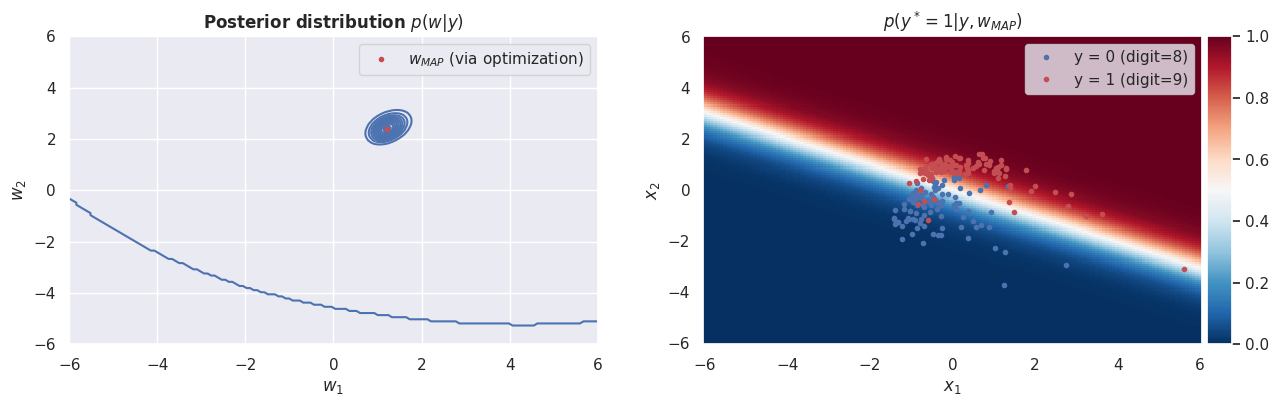

In [18]:
sigmoid = lambda x: 1./(1 + jnp.exp(-x))

class LogisticRegression(object):

    def __init__(self, X, y, feature_transformation=lambda x: x, alpha=1.):
        
        # store data and hyperparameters
        self.X0 = X
        self.y = y
        self.alpha = alpha
        self.feature_transformation = feature_transformation

        # apply feature transformation and standardize
        self.X = feature_transformation(self.X0)
        self.X_mean = jnp.mean(self.X, 0)
        self.X_std = jnp.std(self.X, 0)
        self.X_std.at[self.X_std == 0].set(1)
        self.X = self.preprocess(X)

        # store number of training data and number of features
        self.N, self.D = self.X.shape
        
        # get MAP by optimization
        self.w_MAP = self.get_MAP()

    def preprocess(self, X_):
        X = self.feature_transformation(X_)
        return (X - self.X_mean)/self.X_std
        
    def predict(self, X, w):
        """ evaluates sigma(f(X)) """
        f = w@X.T
        return sigmoid(f)
    
    def log_joint(self, w):
        """
            evaluates log joint, i.e. log p(y, w), for each row in w.
            w is expected to be of shape [M, D], where D is the number of parameters in the model and M is the number of points to evaluated
        """
        p = self.predict(self.X, w)
        log_prior = jnp.sum(log_npdf(w, 0, 1./self.alpha), axis=1)
        log_lik = binom_dist.logpmf(self.y, p=p, n=1)
        log_joint = log_prior + log_lik.sum(axis=1)

        return log_joint
    
    def hessian(self, w):
        """ Returns hessian of log joint evaluated at w 
            Input:   w       (shape: [1, D])
            Returns: H       (shape: [D, D])            """
        
        ##############################################
        # Your solution goes here
        ##############################################
        p = self.predict(self.X, w)
        v = p*(1-p)
        H = -self.X.T @ jnp.diag(v) @ self.X - self.alpha * jnp.identity(self.D)
        
        
        ##############################################
        # End of solution
        ##############################################
        
        assert H.shape == (self.D, self.D), f"The shape of the Hessians appears to be wrong. Expected shape ({self.D}, {self.D}), but received {H.shape}. Check your implementation"
        return H
    def grad(self, w):
        """ Returns gradient of log joint evaluated at w 
            Input:   w          (shape: [1, D])
            Returns: grad       (shape: [1, D])            """
        
        ##############################################
        # Your solution goes here
        ##############################################
        p = self.predict(self.X, w)
        err = p - self.y
        grad = -jnp.sum(err.T * self.X, axis=0) - self.alpha * w
        ##############################################
        # End of solution
        ##############################################

        assert grad.shape == (1, self.D), f"The shape of the gradient appears to be wrong. Expected shape (1, {self.D}), but received {grad.shape}. Check your implementation"
        return grad
  
    def get_MAP(self):
        """ returns MAP estimate obtained by maximizing the log joint """
        init_w = jnp.zeros(self.D)
        results = minimize(lambda x: -self.log_joint(x[None, :]), jac=lambda x: -self.grad(x[None, :]).flatten(), x0=init_w)
        if not results.success:
            print(results)
            raise ValueError('Optization failed')
        
        w_MAP = results.x 
        return w_MAP
    
        
# instantiate model
model = LogisticRegression(Xtrain, ytrain)

# function for making prediction using w_MAP point estimate
pred_MAP = lambda x: model.predict(model.preprocess(x), model.w_MAP)

# prep grid
dim1, dim2 = jnp.linspace(-6, 6, 150), jnp.linspace(-6, 6, 149)
grid_log_joint = Grid2D(dim1, dim2, model.log_joint, name='Posterior distribution $p(w|y)$')
grid_predictions = Grid2D(dim1, dim2, pred_MAP, name='$p(y^*=1|y, w_{MAP})$')

# plot
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
grid_log_joint.plot_contours(ax[0], f=jnp.exp,)
ax[0].plot(model.w_MAP[0], model.w_MAP[1], 'r.', label='$w_{MAP}$ (via optimization)')
ax[0].legend()

plot_data(ax[1], Xtrain, ytrain, 'Training data')
grid_predictions.plot_heatmap(ax[1], colorbar=True)
ax[1].set(xlabel='$x_1$', ylabel='$x_2$');

Using feature transformations, we can model non-linear decision boundaries, but we cannot easily visualize the posterior anymore (**why not?**):

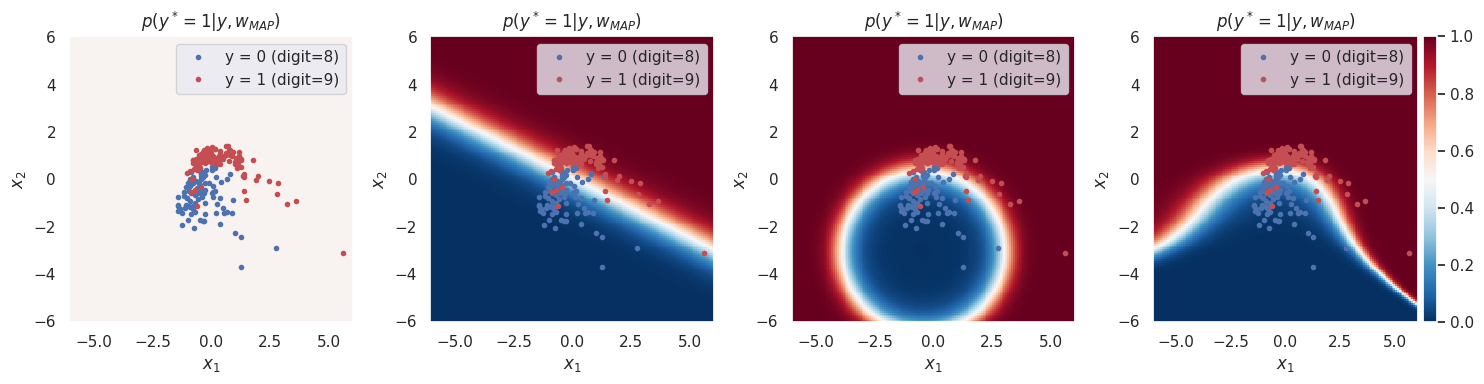

In [19]:
# simple polymials as feature transformation
def feature_transformation(x, order=1):
    return jnp.column_stack([x**m for m in range(order+1)])

# prep grid
dim1, dim2 = jnp.linspace(-6, 6, 150), jnp.linspace(-6, 6, 149)

# plot
fig, ax = plt.subplots(1, 4, figsize=(15, 4))

for i in range(4):

    # instantiate model
    model = LogisticRegression(Xtrain, ytrain, feature_transformation=lambda x: feature_transformation(x, order=i))

    # function for making prediction using w_MAP point estimate
    pred_MAP = lambda x: model.predict(model.preprocess(x), model.w_MAP)

    # evaluate prediction for grid
    grid_predictions = Grid2D(dim1, dim2, pred_MAP, name='$p(y^*=1|y, w_{MAP})$')

    # plot
    plot_data(ax[i], Xtrain, ytrain, 'Training data')
    grid_predictions.plot_heatmap(ax[i], colorbar=True if i == 3 else False)
    ax[i].set(xlabel='$x_1$', ylabel='$x_2$')

fig.tight_layout()

# Part 4:  Implementing the Laplace approximation for logistic regression

We are now ready to implement the Laplace approximation. We have already done most of the hard word, now we simply need to combine all the pieces. For the purpose of validating our implementation, we will temporarily remove the feature transformation again.

**Task 4.1**: Complete the implementation the Laplace approximation below. To verify your implementation, we will generate 200 samples from the posterior, $\textbf{w}^i \sim q(\textbf{w})$ and the plot the samples on top of the contours of posterior distribution. You should expect to see samples covering the contours of the posterior distribution.

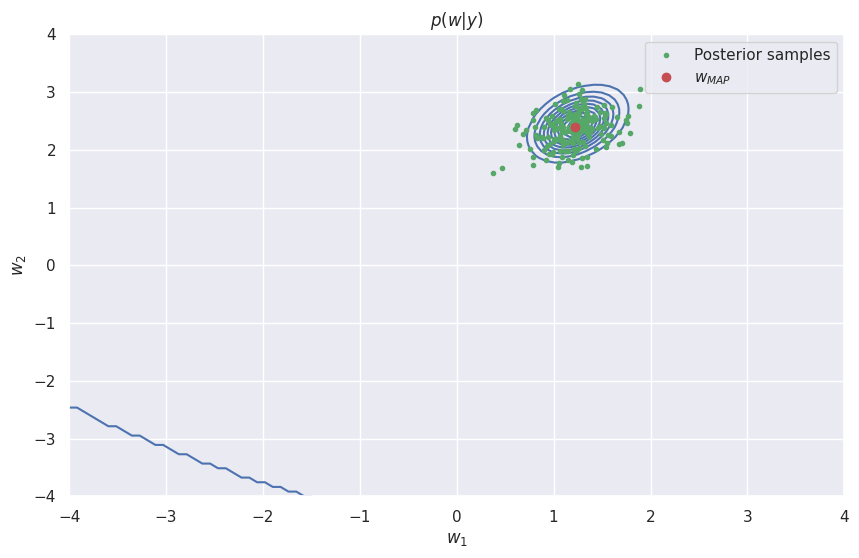

In [28]:
class LaplaceApproximation(object):

    def __init__(self, model):
        """ implements a laplace approximain q(w) = N(m, S), where m is the posterior mean and S is the posterior covariance """

        # store model
        self.model = model

        # implement Laplace approximation
        self.posterior_mean = model.w_MAP                               
        self.posterior_hessian = model.hessian(model.w_MAP)             
        self.posterior_cov = -jnp.linalg.inv(self.posterior_hessian)     

        # sanity check for dimensions
        assert self.posterior_mean.shape == (model.D,), f"The shape of the posterior mean appears wrong. Check your implementaion."
        assert self.posterior_hessian.shape == (model.D, model.D), f"The shape of the posterior Hessian appears wrong. Check your implementaion."
        assert self.posterior_cov.shape == (model.D, model.D), f"The shape of the posterior covariance appears wrong. Check your implementaion."

    def log_pdf(self, w):
        """ evaluate approximate posterior density at w """
        return mvn.logpdf(w, self.posterior_mean.ravel(), self.posterior_cov)
    
    def posterior_samples(self, key, num_samples):
        """ generate samples from posterior distribution """
        return random.multivariate_normal(key, self.posterior_mean, self.posterior_cov, shape=(num_samples, ))

# prep model and approximation
model = LogisticRegression(Xtrain, ytrain)
laplace = LaplaceApproximation(model)

# generate samples from posterior
key = random.PRNGKey(1)
w_samples = laplace.posterior_samples(key, 200)

# prep grid
dim1, dim2 = jnp.linspace(-4, 4, 100), jnp.linspace(-4, 4, 100)
grid_log_joint = Grid2D(dim1, dim2, model.log_joint, name='$p(w|y)$')

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
grid_log_joint.plot_contours(ax, f=jnp.exp)
ax.plot(w_samples[:, 0], w_samples[:, 1], 'g.', label='Posterior samples')
ax.plot(model.w_MAP[0], model.w_MAP[1], 'ro', label='$w_{MAP}$')
ax.legend();



**Task 4.2**: Report the (approximate) posterior mean and covariance of $p(\mathbf{w}|\mathbf{y})$



## Part 5:  Approximating the posterior predictive distribution

Now that we have obtained our Laplace approximation, i.e. $p(\textbf{w}|\textbf{y}) \approx q(\textbf{w}) = \mathcal{N}(\mathbf{w}|\mathbf{m}, \mathbf{S})$, it is finally time to make predictions. Our goal is to approximate the posterior predictive distribution $p(y^* = 1|\mathbf{y}, \mathbf{x}^*)$, which can be approximated as

$$\begin{align*}
p(y^*=1|\textbf{y}, \textbf{x}^*) = \int p(y^*=1|\textbf{w}, \textbf{x}^*) p(\textbf{w}|\textbf{y}) \text{d}\textbf{w} \approx \int p(y^*=1|\textbf{w}, \textbf{x}^*) q(\textbf{w}) \text{d}\textbf{w} = \int \sigma(\mathbf{w}^T \mathbf{x}^*) \mathcal{N}(\mathbf{w}|\mathbf{m}, \mathbf{S}) \text{d} \mathbf{w} = \int \sigma(f^*) \mathcal{N}(f^*|m^*, v^*) \text{d} f^*,
\end{align*}$$

where $m^* = \mathbf{m}^T \mathbf{x} ^*$ and  and $v^* = (\mathbf{x}^*)^T  \mathbf{S} \mathbf{x}_*$. In this exercise, we will implement three options for approximating the above integral:

**The plug-in approximation**

The first option is the **plug-in** aproximation using $\mathbf{m} = \mathbf{w}_{\text{MAP}}$:

$$\begin{align*}
p(y^*=1|\textbf{y}, \textbf{x}^*) \approx \sigma(m^*)
\end{align*}$$

This option is simple and very fast, but the drawback is that it ignores any posterior uncertainty for $f^*$.

**The probit approximation**

The second approach we will consider is the so-called **probit** approximation:

$$\begin{align*}
p(y^*=1|\textbf{y}, \textbf{x}^*) \approx \int \sigma(f^*) \mathcal{N}(f^*|m^*, v^*) \text{d} f^* \approx \int \Phi(f^* \sqrt{\frac{\pi}{8}}) \mathcal{N}(f^*|m^*, v^*) \text{d} f^* = \Phi\left(\frac{m^*}{\sqrt{\frac{8}{\pi} + v^*}}\right),
\end{align*}$$

where $\Phi(\cdot): \mathbb{R} \rightarrow (0,1)$ is the CDF of a standardized Gaussian distribution. The option is also fast, but comes with a small bias.


**The Monte Carlo estimator**

The third and last option is a Monte Carlo estimator:

$$\begin{align*}
p(y^*=1|\textbf{y}, \textbf{x}^*) \approx \frac{1}{S} \sum_{i=1}^S \sigma(f^*_{(i)}), \quad \text{where} \quad f^*_{(i)} \sim \mathcal{N}(f^*|m^*, v^*) \quad \text{for} \quad i = 1, ..., S
\end{align*}$$

We can make this estimator as precise as we want by increasing the number of Monte Carlo samples $S$. Of course, there is a trade between precision and computational cost. 




**Task 5.1**: Complete the implementation of the functions `montecarlo` and `probit_approx` in the class below for computing the Monte Carlo estimator and the probit approximation, respectively.

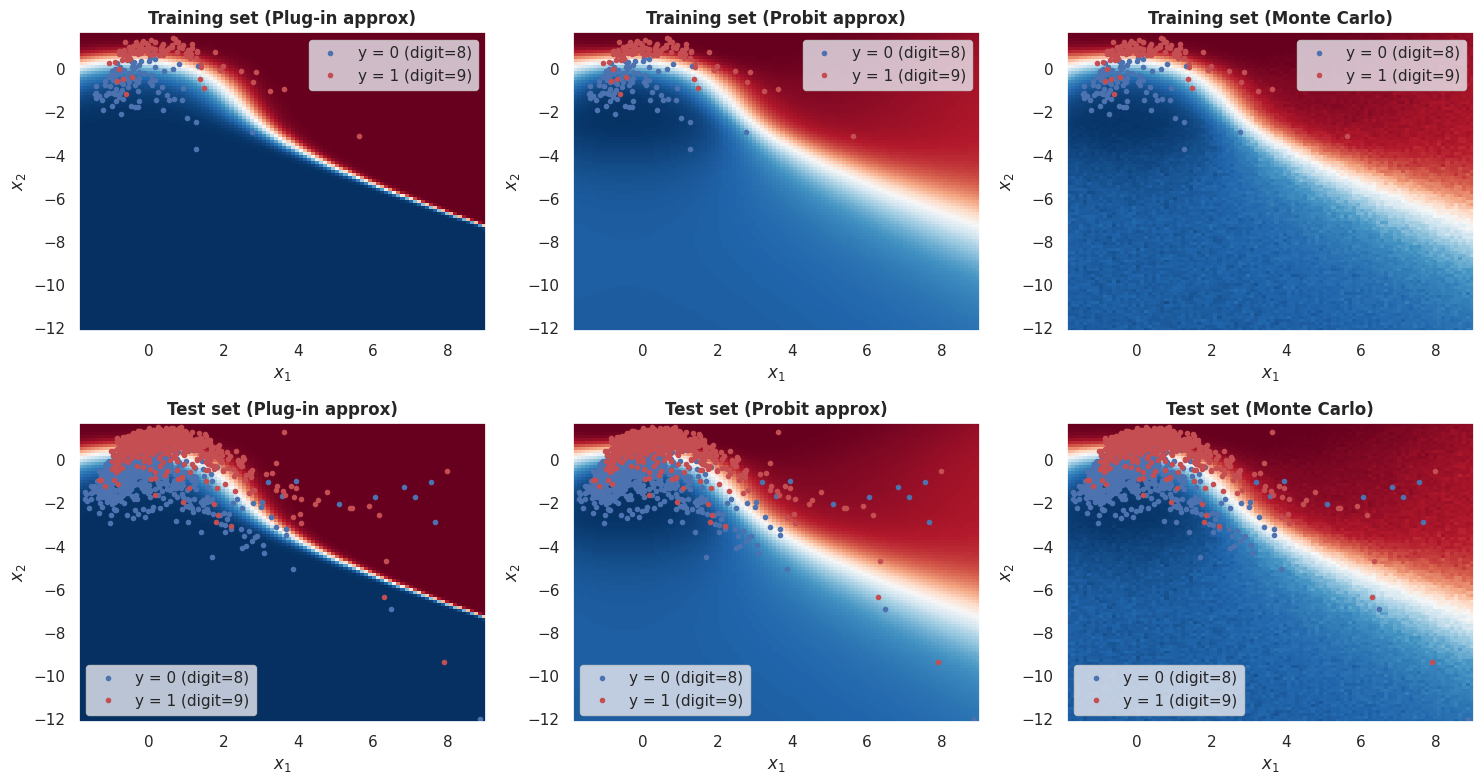

In [30]:
probit = lambda x: norm_dist.cdf(x)

class PosteriorPredictiveDistribution(object):
    
    def  __init__(self, model):
        self.model = model
        self.feature_transformation = model.feature_transformation
        self.laplace = LaplaceApproximation(model)

    def posterior_f(self, xstar_):
        """ computes the mean and variance of f^* = w^T x^* """
        xstar = self.model.preprocess(xstar_)
        m = xstar@self.laplace.posterior_mean
        v = jnp.diag(xstar@self.laplace.posterior_cov@xstar.T)
        return m, v

    def plugin_approx(self, xstar_):
        """ implements the plugin approximation for p(y^*|y, x^*) using w_MAP. If xstar has shape (M, D), then the shape of the output p must be (M,) """
        xstar = self.model.preprocess(xstar_)
        p = model.predict(xstar, model.w_MAP)

        assert p.shape == (len(xstar_),), f"Expected the shape of the output from the Monte Carlo approximation to be ({len(xstar)},), but the received shape was {p.shape}"
        return p
    
    def montecarlo(self, xstar, num_samples=1000, seed=0):
        """ implements the Monte Carlo estimator for p(y^*|y, x^*). If xstar has shape (M, D), then the shape of the output p must be (M,) """
        m, v = self.posterior_f(xstar)

        ##############################################
        # Your solution goes here
        ##############################################
        
        key = random.PRNGKey(seed)
        f = m  + jnp.sqrt(v)*random.normal(key, shape=(num_samples, len(xstar)))
        p = sigmoid(f).mean(0)
        
        ##############################################
        # End of solution
        ##############################################

        assert p.shape == (len(xstar),), f"Expected the shape of the output from the Monte Carlo approximation to be ({len(xstar)},), but the received shape was {p.shape}"
        return p

    def probit_approx(self, xstar):
        """ implements the probit approximation for p(y^*|y, x^*). If xstar has shape (M, D), then the shape of the output p must be (M,) """
        m, v = self.posterior_f(xstar)

        ##############################################
        # Your solution goes here
        ##############################################
        
        p = probit(m/jnp.sqrt(8/jnp.pi + v))
        
        ##############################################
        # End of solution
        ##############################################

        assert p.shape == (len(xstar),), f"Expected the shape of the output from the Monte Carlo approximation to be ({len(xstar)},), but the received shape was {p.shape}"
        return p
    
# simple polymials as feature transformation
def feature_transformation(x, order=1):
    return jnp.column_stack([x**m for m in range(order+1)])

# set up model and posterior predictive distribution
model = LogisticRegression(Xtrain, ytrain, feature_transformation=lambda x: feature_transformation(x, 3))
postpred = PosteriorPredictiveDistribution(model)

pred_dict = {   'Plug-in approx': postpred.plugin_approx,
                'Probit approx':  postpred.probit_approx,
                'Monte Carlo':    postpred.montecarlo,
            }


dim1 = jnp.linspace(Xtest[:, 0].min()-0.1, Xtest[:, 0].max()+0.1, 100)
dim2 = jnp.linspace(Xtest[:, 1].min()-0.1, Xtest[:, 1].max()+0.1, 100)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
    
for i, (name, predict_func) in enumerate(pred_dict.items()):
    predict_grid = Grid2D(dim1, dim2, predict_func)

    plot_data(ax[0, i], Xtrain, ytrain, alpha=0.5)
    plot_data(ax[1, i], Xtest, ytest, alpha=0.5)
    predict_grid.plot_heatmap(ax[0, i])
    predict_grid.plot_heatmap(ax[1, i])
    ax[0, i].set_title(f'Training set ({name})', fontweight='bold')
    ax[1, i].set_title(f'Test set ({name})', fontweight='bold')
    ax[0, i].set(xlabel='$x_1$', ylabel='$x_2$')
    ax[1, i].set(xlabel='$x_1$', ylabel='$x_2$')


fig.tight_layout()




**Task 5.2**: Study the maps of the posterior predictive probability above and comment and the qualitative differences [**Discussion question**].

**Task 5.3**: Compute the training and test accuracy and ELPD for each of the three approximations:

*Hint: the ELPD may evaluate to -infinity for the plug-in approximation for numerical reasons. The problem is that we are first computing the predictive probability and then computing the ELPD. This is problematic when the predicted probabilities become either 0 or 1 to due to numerical underflow/overflow. However, this problem can be avoided by evaluating the ELPDs using the log probabilities instead.*



In [31]:
print(70*'*')
print(f'Method\t\t\tMetric\t\tTraining\tTest')
print(70*'*')
# loop over metrics
for metric_name, metric_fun in metrics.items():
    # loop over methods
    for method_name, predict_func in pred_dict.items():

        # make predictions for both training and test set
        p_train_hat = predict_func(Xtrain)
        p_test_hat = predict_func(Xtest)

        # print
        print(f'{method_name:24s}{metric_name:15s}\t{metric_fun(ytrain, p_train_hat):+3.2f}\t\t{metric_fun(ytest, p_test_hat):+3.2f}')
    print()

**********************************************************************
Method			Metric		Training	Test
**********************************************************************
Plug-in approx          Accuracy       	+0.91		+0.91
Probit approx           Accuracy       	+0.91		+0.91
Monte Carlo             Accuracy       	+0.91		+0.91

Plug-in approx          ELPD           	-0.25		-inf
Probit approx           ELPD           	-0.25		-0.25
Monte Carlo             ELPD           	-0.25		-0.26



# Part 6:  Insights into the posterior predictive distribution via the probit approximation

Besides being a very and accurate approximation of the posterior predictive distribution, we also use the probit approximation to gain insight into the behaviour of the model. The following task shows that if the posterior uncertainty of the parameters becomes sufficiently, i.e. $v^* = (\mathbf{x}^*)^T  \mathbf{S} \mathbf{x}_*$, then the posterior predictive distribution will be approach $\frac{1}{2}$.


**Task 6.1**: Show that the posterior predictive probability $p(y^*=1|\textbf{y}, \mathbf{x}) \rightarrow 0.5$ as the variance $v^* \rightarrow \infty$.

*Hints: What happens to $\frac{m^*}{\sqrt{\frac{8}{\pi} + v^*}}$ as $v^*$ increases?*




**Task 6.2**: Show/argue that the plug-in approximation and the probit approximation generate the same **decisions** if we use the decision rule $y^* = \arg\max_{k} p(y^*=k|\textbf{y}, \textbf{x}^*)$.


